In [1]:
import numpy as np

def get_predict_mask(probs):
    preds = np.round(probs)
    return preds

probs = np.array([
    [0.5, 0.2, 0.9],
    [0.99, 0, 1],
    [1, 0.003, 0.8]
])
predict_mask = get_predict_mask(probs)
predict_mask

array([[0., 0., 1.],
       [1., 0., 1.],
       [1., 0., 1.]])

In [2]:
def get_shrub_locs(predict_mask):
    locs = np.argwhere(predict_mask == 1)
    return locs

shrub_locs = get_shrub_locs(predict_mask)
shrub_locs

array([[0, 2],
       [1, 0],
       [1, 2],
       [2, 0],
       [2, 2]])

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ============================================================================
# SAMPLE DATA CREATION: Real-world test images with labeled shrubs
# ============================================================================

def create_sample_shrub_images(num_samples=8):
    """Create realistic shrub binary masks for testing ensemble"""
    images = []
    masks = []
    descriptions = []
    true_counts = []
    
    # Sample 1: Sparse (few large shrubs)
    img1 = np.zeros((256, 256), dtype=np.float32)
    mask1 = np.zeros((256, 256), dtype=np.uint8)
    for cx, cy, r in [(60, 60, 30), (180, 100, 35), (100, 200, 25)]:
        cv2.circle(img1, (cx, cy), r, 1.0, -1)
        cv2.circle(mask1, (cx, cy), r, 1, -1)
    images.append(img1)
    masks.append(mask1)
    descriptions.append("Sparse (3 large shrubs)")
    true_counts.append(3)
    
    # Sample 2: Dense (many small shrubs)
    img2 = np.zeros((256, 256), dtype=np.float32)
    mask2 = np.zeros((256, 256), dtype=np.uint8)
    np.random.seed(42)
    for _ in range(12):
        cx, cy = np.random.randint(30, 226, 2)
        r = np.random.randint(10, 18)
        cv2.circle(img2, (cx, cy), r, 1.0, -1)
        cv2.circle(mask2, (cx, cy), r, 1, -1)
    images.append(img2)
    masks.append(mask2)
    descriptions.append("Dense (12 small shrubs)")
    true_counts.append(12)
    
    # Sample 3: Mixed sizes
    img3 = np.zeros((256, 256), dtype=np.float32)
    mask3 = np.zeros((256, 256), dtype=np.uint8)
    for cx, cy, r in [(50, 80, 20), (120, 60, 15), (200, 100, 25), (80, 180, 12), (160, 200, 18)]:
        cv2.circle(img3, (cx, cy), r, 1.0, -1)
        cv2.circle(mask3, (cx, cy), r, 1, -1)
    images.append(img3)
    masks.append(mask3)
    descriptions.append("Mixed sizes (5 shrubs)")
    true_counts.append(5)
    
    # Sample 4: Overlapping shrubs (challenging)
    img4 = np.zeros((256, 256), dtype=np.float32)
    mask4 = np.zeros((256, 256), dtype=np.uint8)
    for cx, cy, r in [(80, 80, 25), (110, 90, 25), (140, 85, 25), (200, 150, 30)]:
        cv2.circle(img4, (cx, cy), r, 1.0, -1)
        cv2.circle(mask4, (cx, cy), r, 1, -1)
    images.append(img4)
    masks.append(mask4)
    descriptions.append("Overlapping (4 shrubs)")
    true_counts.append(4)
    
    # Sample 5: Edge cases (very small)
    img5 = np.zeros((256, 256), dtype=np.float32)
    mask5 = np.zeros((256, 256), dtype=np.uint8)
    for cx, cy, r in [(50, 50, 8), (100, 100, 7), (150, 150, 9), (200, 200, 8)]:
        cv2.circle(img5, (cx, cy), r, 1.0, -1)
        cv2.circle(mask5, (cx, cy), r, 1, -1)
    images.append(img5)
    masks.append(mask5)
    descriptions.append("Very small (4 tiny shrubs)")
    true_counts.append(4)
    
    # Large-scale test cases: 40, 50, 60, 70, 80, 90, 100 shrubs
    np.random.seed(123)
    for shrub_count in [40, 50, 60, 70, 80, 90, 100]:
        img = np.zeros((256, 256), dtype=np.float32)
        mask = np.zeros((256, 256), dtype=np.uint8)
        
        # Generate random positions and sizes for shrubs
        for _ in range(shrub_count):
            cx = np.random.randint(20, 236)
            cy = np.random.randint(20, 236)
            r = np.random.randint(4, 10)  # Smaller radii for more shrubs
            cv2.circle(img, (cx, cy), r, 1.0, -1)
            cv2.circle(mask, (cx, cy), r, 1, -1)
        
        images.append(img)
        masks.append(mask)
        descriptions.append(f"Large-scale ({shrub_count} shrubs)")
        true_counts.append(shrub_count)
    
    return np.array(images), np.array(masks), descriptions, true_counts

sample_images, sample_masks, mask_descriptions, true_counts = create_sample_shrub_images(12)

print("✓ Sample Data Created")
print(f"  Images shape: {sample_images.shape}")
print(f"  Masks shape: {sample_masks.shape}")
print(f"  Samples: {len(mask_descriptions)}")

✓ Sample Data Created
  Images shape: (12, 256, 256)
  Masks shape: (12, 256, 256)
  Samples: 12


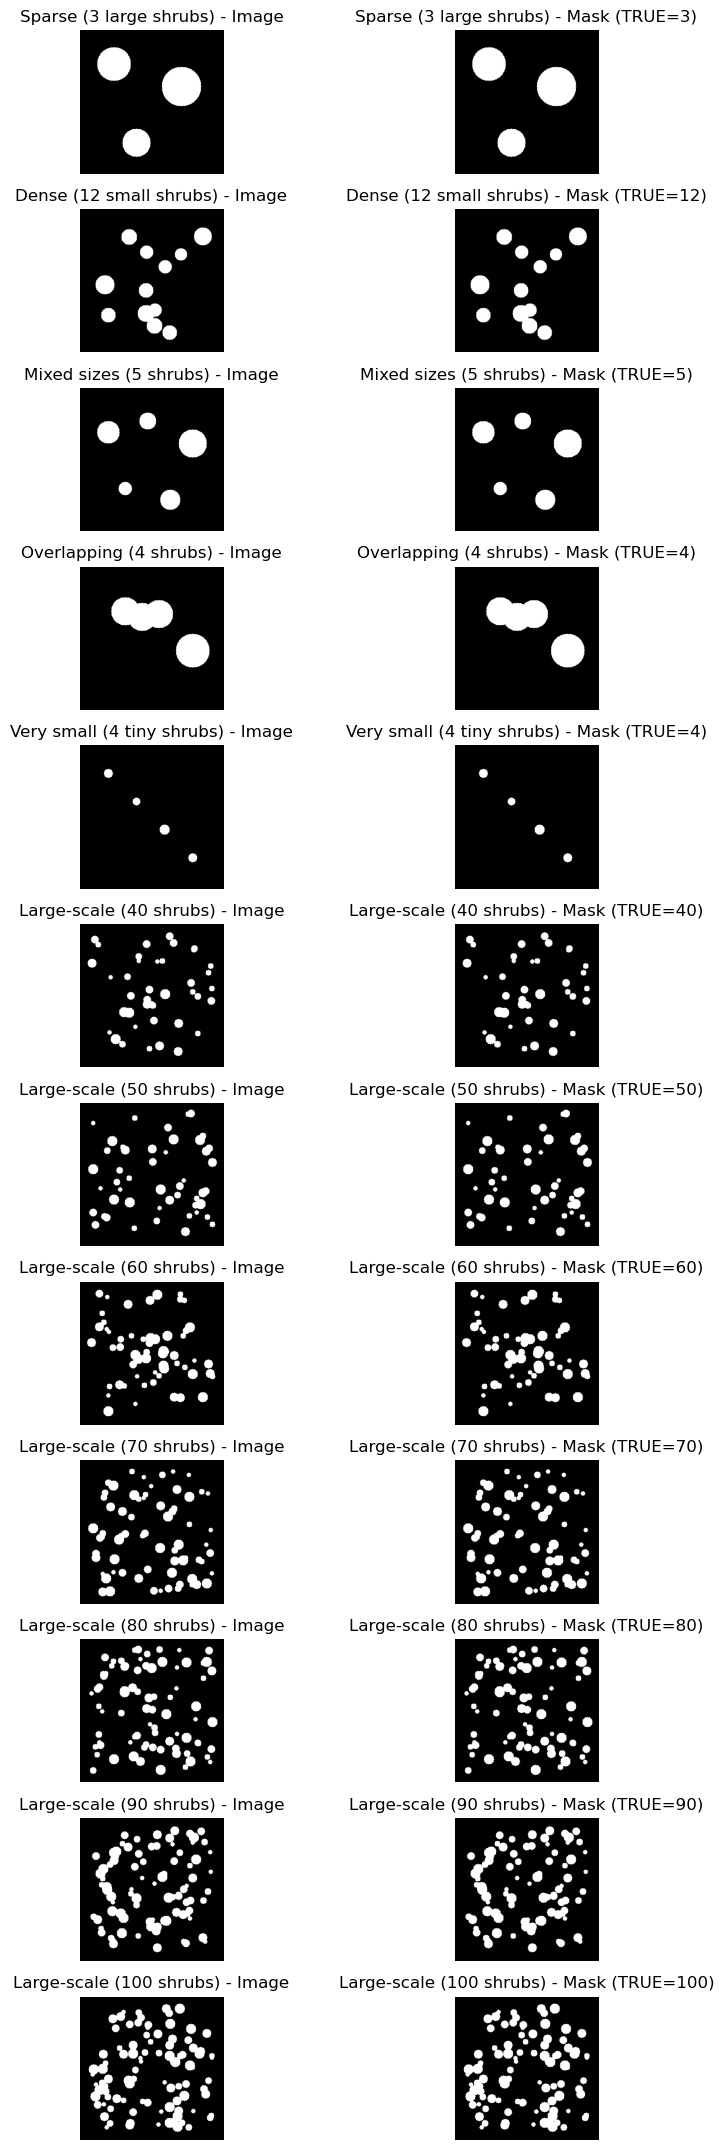

✓ Sample data visualization saved


In [5]:
# ============================================================================
# SAMPLE DATA 2D VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(len(sample_images), 2, figsize=(10, len(sample_images)*1.8))

for idx, (img, mask, desc, true_count) in enumerate(zip(sample_images, sample_masks, mask_descriptions, true_counts)):
    # Image
    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].set_title(f'{desc} - Image')
    axes[idx, 0].axis('off')
    
    # Mask
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f'{desc} - Mask (TRUE={true_count})')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig('sample_data_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Sample data visualization saved")

In [6]:
# ============================================================================
# ENSEMBLE FUNCTIONS: 5 Different Shrub Counting Algorithms
# ============================================================================

from skimage.segmentation import watershed
from skimage.feature import blob_log

def count_shrubs_ccl(binary_mask):
    """Connected Component Labeling"""
    labeled_array, num_features = ndimage.label(binary_mask)
    return num_features, labeled_array

def count_shrubs_watershed(binary_mask):
    """Watershed segmentation"""
    # Distance transform
    dist_transform = ndimage.distance_transform_edt(binary_mask)
    # Find local maxima as markers
    local_maxima = ndimage.maximum_filter(dist_transform, size=7) == dist_transform
    markers = ndimage.label(local_maxima)[0]
    # Watershed
    segmented = watershed(-dist_transform, markers, mask=binary_mask) if np.any(binary_mask) else np.zeros_like(binary_mask)
    num_objects = len(np.unique(segmented)) - 1
    return num_objects, segmented

def count_shrubs_morphological(binary_mask, kernel_size=5):
    """Morphological opening to separate shrubs"""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    labeled_array, num_features = ndimage.label(opened)
    return num_features, labeled_array

def count_shrubs_blob_log(binary_mask, min_sigma=5, max_sigma=30):
    """Laplacian of Gaussian blob detection"""
    if np.any(binary_mask) == 0:
        return 0, binary_mask
    try:
        blobs = blob_log(binary_mask, min_sigma=min_sigma, max_sigma=max_sigma, threshold=0.1)
        return len(blobs), binary_mask
    except:
        return 0, binary_mask

def count_shrubs_dbscan(binary_mask, eps=10, min_samples=5):
    """DBSCAN clustering on object pixels"""
    if np.any(binary_mask) == 0:
        return 0, binary_mask
    points = np.column_stack(np.where(binary_mask > 0))
    if len(points) < min_samples:
        return 1, binary_mask
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    return len(set(clustering.labels_)), binary_mask

print("✓ Ensemble functions loaded: CCL, Watershed, Morphological, LoG, DBSCAN")

✓ Ensemble functions loaded: CCL, Watershed, Morphological, LoG, DBSCAN


In [7]:
# ============================================================================
# SIMPLE ENSEMBLE: Averaged Predictions with Outlier Rejection
# ============================================================================

def ensemble_predict_shrub_count(binary_mask, verbose=False):
    """
    Simple ensemble: Average predictions from 5 algorithms with outlier rejection.
    
    Parameters:
        binary_mask: Binary segmentation mask (0s and 1s)
        verbose: Print detailed breakdown
    
    Returns:
        final_count: Final ensemble shrub count
        predictions_dict: Individual algorithm predictions
    """
    
    # Get predictions from each algorithm
    ccl_count, _ = count_shrubs_ccl(binary_mask)
    watershed_count, _ = count_shrubs_watershed(binary_mask)
    morph_count, _ = count_shrubs_morphological(binary_mask)
    blob_count = count_shrubs_blob_log(binary_mask)[0]
    dbscan_count = count_shrubs_dbscan(binary_mask)[0]
    
    predictions = {
        'CCL': ccl_count,
        'Watershed': watershed_count,
        'Morphological': morph_count,
        'LoG': blob_count,
        'DBSCAN': dbscan_count
    }
    
    # Calculate statistics
    pred_values = np.array(list(predictions.values()))
    mean_pred = np.mean(pred_values)
    std_pred = np.std(pred_values)
    median_pred = np.median(pred_values)
    
    # Outlier rejection: Keep predictions within 1 std of mean
    lower_bound = mean_pred - 1 * std_pred
    upper_bound = mean_pred + 1 * std_pred
    kept_predictions = pred_values[(pred_values >= lower_bound) & (pred_values <= upper_bound)]
    
    # Final estimate
    if len(kept_predictions) > 0:
        final_estimate = np.mean(kept_predictions)
    else:
        final_estimate = median_pred
    
    final_count = int(np.round(final_estimate))
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"ENSEMBLE PREDICTION")
        print(f"{'='*70}")
        print(f"\nIndividual Algorithm Predictions:")
        for algo, pred in predictions.items():
            status = "✓" if (pred >= lower_bound and pred <= upper_bound) else "✗"
            print(f"  {status} {algo:20s}: {pred:3d}")
        print(f"\nEnsemble Statistics:")
        print(f"  Mean: {mean_pred:7.2f} | Std: {std_pred:7.2f} | Median: {median_pred:7.1f}")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Kept: {len(kept_predictions)}/{len(pred_values)} predictions")
        print(f"\nFinal Estimate: {final_count} shrubs")
        print(f"{'='*70}")
    
    return final_count, predictions

print("✓ Simple ensemble function ready")

✓ Simple ensemble function ready


In [8]:
# ============================================================================
# PREDICT SHRUB COUNTS USING ENSEMBLE
# ============================================================================

print("\n" + "="*80)
print("ENSEMBLE SHRUB COUNTING PREDICTIONS ON SAMPLE DATA")
print("="*80)

all_results = []

for mask_idx, (mask, true_count, desc) in enumerate(zip(sample_masks, true_counts, mask_descriptions)):
    # Get ensemble prediction
    predicted_count, individual_preds = ensemble_predict_shrub_count(mask, verbose=True)
    
    # Calculate error
    error = predicted_count - true_count
    accuracy_1 = 1 if abs(error) <= 1 else 0
    accuracy_2 = 1 if abs(error) <= 2 else 0
    
    all_results.append({
        'sample': mask_idx + 1,
        'description': desc,
        'true_count': true_count,
        'predicted_count': predicted_count,
        'error': error,
        'within_1': accuracy_1,
        'within_2': accuracy_2,
        'predictions': individual_preds
    })

# Summary statistics
print("\n" + "="*80)
print("ENSEMBLE SUMMARY STATISTICS")
print("="*80)

errors = np.array([r['error'] for r in all_results])
mae = np.mean(np.abs(errors))
acc1 = np.mean([r['within_1'] for r in all_results]) * 100
acc2 = np.mean([r['within_2'] for r in all_results]) * 100

print(f"\nMean Absolute Error (MAE): {mae:.3f}")
print(f"Accuracy ±1 shrub: {acc1:.1f}%")
print(f"Accuracy ±2 shrubs: {acc2:.1f}%")

# Print table
print(f"\n{'Sample':<8} {'Description':<25} {'True':<6} {'Pred':<6} {'Error':<7} {'±1':<4} {'±2':<4}")
print("-" * 80)
for result in all_results:
    within_1_str = "✓" if result['within_1'] else "✗"
    within_2_str = "✓" if result['within_2'] else "✗"
    print(f"{result['sample']:<8} {result['description']:<25} {result['true_count']:<6} "
          f"{result['predicted_count']:<6} {result['error']:+7} {within_1_str:<4} {within_2_str:<4}")

print("\n" + "="*80)
print(f"✓ Ensemble predictions complete!")
print(f"  Total samples: {len(all_results)}")
print(f"  Average accuracy ±1: {acc1:.1f}%")
print(f"  Average MAE: {mae:.3f}")
print("="*80)


ENSEMBLE SHRUB COUNTING PREDICTIONS ON SAMPLE DATA

ENSEMBLE PREDICTION

Individual Algorithm Predictions:
  ✓ CCL                 :   3
  ✓ Watershed           :   3
  ✓ Morphological       :   3
  ✗ LoG                 :   0
  ✓ DBSCAN              :   3

Ensemble Statistics:
  Mean:    2.40 | Std:    1.20 | Median:     3.0
  Bounds: [1.20, 3.60]
  Kept: 4/5 predictions

Final Estimate: 3 shrubs

ENSEMBLE PREDICTION

Individual Algorithm Predictions:
  ✓ CCL                 :  10
  ✓ Watershed           :  12
  ✓ Morphological       :  10
  ✗ LoG                 :   0
  ✓ DBSCAN              :   9

Ensemble Statistics:
  Mean:    8.20 | Std:    4.21 | Median:    10.0
  Bounds: [3.99, 12.41]
  Kept: 4/5 predictions

Final Estimate: 10 shrubs

ENSEMBLE PREDICTION

Individual Algorithm Predictions:
  ✓ CCL                 :   5
  ✓ Watershed           :   5
  ✓ Morphological       :   5
  ✗ LoG                 :   0
  ✓ DBSCAN              :   5

Ensemble Statistics:
  Mean:    4.00 | 

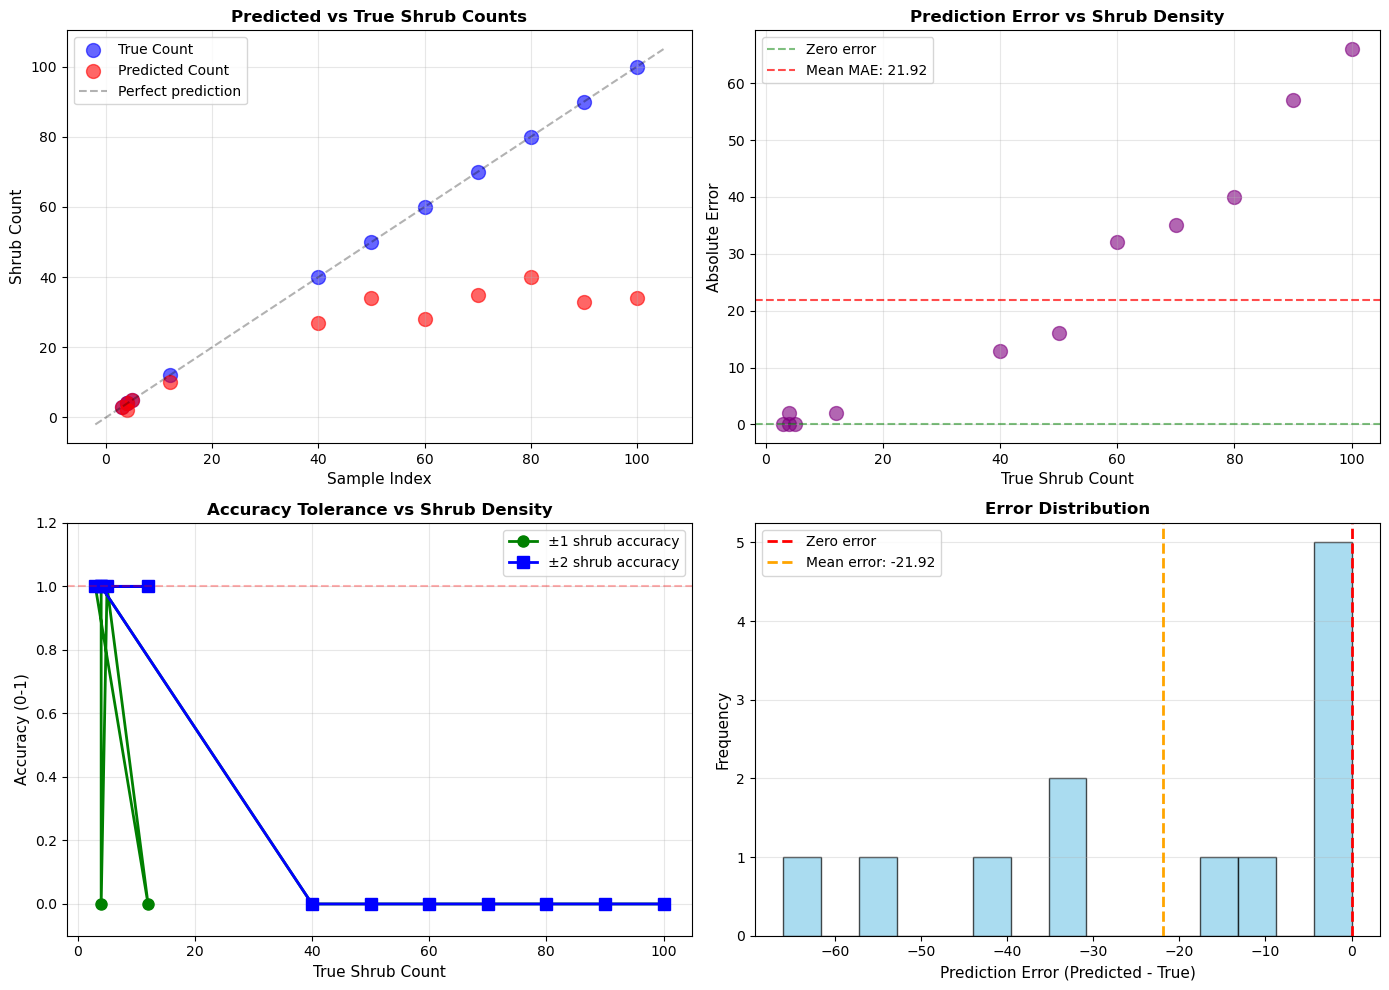

✓ Accuracy vs sample size plot saved


In [9]:
# ============================================================================
# ACCURACY VS SAMPLE SIZE ANALYSIS
# ============================================================================

# Extract true counts and corresponding metrics
sample_sizes = [r['true_count'] for r in all_results]
predicted_counts = [r['predicted_count'] for r in all_results]
errors = [r['error'] for r in all_results]
absolute_errors = [abs(e) for e in errors]
within_1_list = [r['within_1'] for r in all_results]
within_2_list = [r['within_2'] for r in all_results]

# Create comprehensive plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs True counts
ax1 = axes[0, 0]
ax1.scatter(sample_sizes, true_counts, label='True Count', s=100, alpha=0.6, color='blue')
ax1.scatter(sample_sizes, predicted_counts, label='Predicted Count', s=100, alpha=0.6, color='red')
ax1.plot([min(sample_sizes)-5, max(sample_sizes)+5], [min(sample_sizes)-5, max(sample_sizes)+5], 'k--', alpha=0.3, label='Perfect prediction')
ax1.set_xlabel('Sample Index', fontsize=11)
ax1.set_ylabel('Shrub Count', fontsize=11)
ax1.set_title('Predicted vs True Shrub Counts', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Absolute error vs sample size
ax2 = axes[0, 1]
ax2.scatter(sample_sizes, absolute_errors, s=100, alpha=0.6, color='purple')
ax2.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Zero error')
ax2.axhline(y=np.mean(absolute_errors), color='red', linestyle='--', alpha=0.7, label=f'Mean MAE: {np.mean(absolute_errors):.2f}')
ax2.set_xlabel('True Shrub Count', fontsize=11)
ax2.set_ylabel('Absolute Error', fontsize=11)
ax2.set_title('Prediction Error vs Shrub Density', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Accuracy within tolerance vs sample size
ax3 = axes[1, 0]
ax3.plot(sample_sizes, within_1_list, marker='o', linewidth=2, markersize=8, label='±1 shrub accuracy', color='green')
ax3.plot(sample_sizes, within_2_list, marker='s', linewidth=2, markersize=8, label='±2 shrub accuracy', color='blue')
ax3.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax3.set_xlabel('True Shrub Count', fontsize=11)
ax3.set_ylabel('Accuracy (0-1)', fontsize=11)
ax3.set_title('Accuracy Tolerance vs Shrub Density', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-0.1, 1.2)

# Plot 4: Error distribution
ax4 = axes[1, 1]
ax4.hist(errors, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax4.axvline(x=np.mean(errors), color='orange', linestyle='--', linewidth=2, label=f'Mean error: {np.mean(errors):.2f}')
ax4.set_xlabel('Prediction Error (Predicted - True)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('accuracy_vs_sample_size.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Accuracy vs sample size plot saved")

In [10]:
# ============================================================================
# MULTI-RUN ENSEMBLE AVERAGING: Test with 5-10 iterations per sample
# ============================================================================

print("\n" + "="*80)
print("MULTI-RUN ENSEMBLE AVERAGING (5 ITERATIONS PER SAMPLE)")
print("="*80)

num_iterations = 5
multirun_results = []

for mask_idx, (mask, true_count, desc) in enumerate(zip(sample_masks, true_counts, mask_descriptions)):
    print(f"\n[Sample {mask_idx+1}/{len(sample_masks)}] {desc}")
    
    # Run ensemble prediction multiple times
    predictions_list = []
    
    for iteration in range(num_iterations):
        predicted_count, individual_preds = ensemble_predict_shrub_count(mask, verbose=False)
        predictions_list.append(predicted_count)
    
    # Average the predictions across iterations
    mean_prediction = np.mean(predictions_list)
    median_prediction = np.median(predictions_list)
    std_prediction = np.std(predictions_list)
    
    # Final estimate (rounded mean)
    final_count = int(np.round(mean_prediction))
    
    # Calculate error
    error = final_count - true_count
    accuracy_1 = 1 if abs(error) <= 1 else 0
    accuracy_2 = 1 if abs(error) <= 2 else 0
    
    multirun_results.append({
        'sample': mask_idx + 1,
        'description': desc,
        'true_count': true_count,
        'mean_prediction': mean_prediction,
        'median_prediction': median_prediction,
        'std_prediction': std_prediction,
        'final_count': final_count,
        'error': error,
        'within_1': accuracy_1,
        'within_2': accuracy_2,
        'predictions_list': predictions_list
    })
    
    print(f"  Predictions across {num_iterations} runs: {predictions_list}")
    print(f"  Mean: {mean_prediction:.2f} | Median: {median_prediction:.1f} | Std: {std_prediction:.2f}")
    print(f"  Final: {final_count} (True: {true_count}, Error: {error:+d})")

# Summary statistics for multi-run results
print("\n" + "="*80)
print("MULTI-RUN ENSEMBLE SUMMARY STATISTICS")
print("="*80)

errors_multirun = np.array([r['error'] for r in multirun_results])
mae_multirun = np.mean(np.abs(errors_multirun))
acc1_multirun = np.mean([r['within_1'] for r in multirun_results]) * 100
acc2_multirun = np.mean([r['within_2'] for r in multirun_results]) * 100

print(f"\nMean Absolute Error (MAE): {mae_multirun:.3f}")
print(f"Accuracy ±1 shrub: {acc1_multirun:.1f}%")
print(f"Accuracy ±2 shrubs: {acc2_multirun:.1f}%")

# Print comparison table
print(f"\n{'Sample':<8} {'Description':<25} {'True':<6} {'Multi-Run':<12} {'Error':<7} {'±1':<4} {'±2':<4}")
print("-" * 80)
for result in multirun_results:
    within_1_str = "✓" if result['within_1'] else "✗"
    within_2_str = "✓" if result['within_2'] else "✗"
    multi_run_str = f"{result['final_count']}" if result['std_prediction'] < 1.0 else f"{result['mean_prediction']:.1f}±{result['std_prediction']:.1f}"
    print(f"{result['sample']:<8} {result['description']:<25} {result['true_count']:<6} {multi_run_str:<12} "
          f"{result['error']:+7} {within_1_str:<4} {within_2_str:<4}")

print("\n" + "="*80)
print(f"✓ Multi-run ensemble testing complete!")
print(f"  Total samples: {len(multirun_results)}")
print(f"  Iterations per sample: {num_iterations}")
print(f"  Average accuracy ±1: {acc1_multirun:.1f}%")
print(f"  Average MAE: {mae_multirun:.3f}")
print("="*80)



MULTI-RUN ENSEMBLE AVERAGING (5 ITERATIONS PER SAMPLE)

[Sample 1/12] Sparse (3 large shrubs)
  Predictions across 5 runs: [3, 3, 3, 3, 3]
  Mean: 3.00 | Median: 3.0 | Std: 0.00
  Final: 3 (True: 3, Error: +0)

[Sample 2/12] Dense (12 small shrubs)
  Predictions across 5 runs: [10, 10, 10, 10, 10]
  Mean: 10.00 | Median: 10.0 | Std: 0.00
  Final: 10 (True: 12, Error: -2)

[Sample 3/12] Mixed sizes (5 shrubs)
  Predictions across 5 runs: [5, 5, 5, 5, 5]
  Mean: 5.00 | Median: 5.0 | Std: 0.00
  Final: 5 (True: 5, Error: +0)

[Sample 4/12] Overlapping (4 shrubs)
  Predictions across 5 runs: [2, 2, 2, 2, 2]
  Mean: 2.00 | Median: 2.0 | Std: 0.00
  Final: 2 (True: 4, Error: -2)

[Sample 5/12] Very small (4 tiny shrubs)
  Predictions across 5 runs: [4, 4, 4, 4, 4]
  Mean: 4.00 | Median: 4.0 | Std: 0.00
  Final: 4 (True: 4, Error: +0)

[Sample 6/12] Large-scale (40 shrubs)
  Predictions across 5 runs: [27, 27, 27, 27, 27]
  Mean: 27.00 | Median: 27.0 | Std: 0.00
  Final: 27 (True: 40, Error:


IMAGE SIZE AND SHRUB DENSITY ANALYSIS


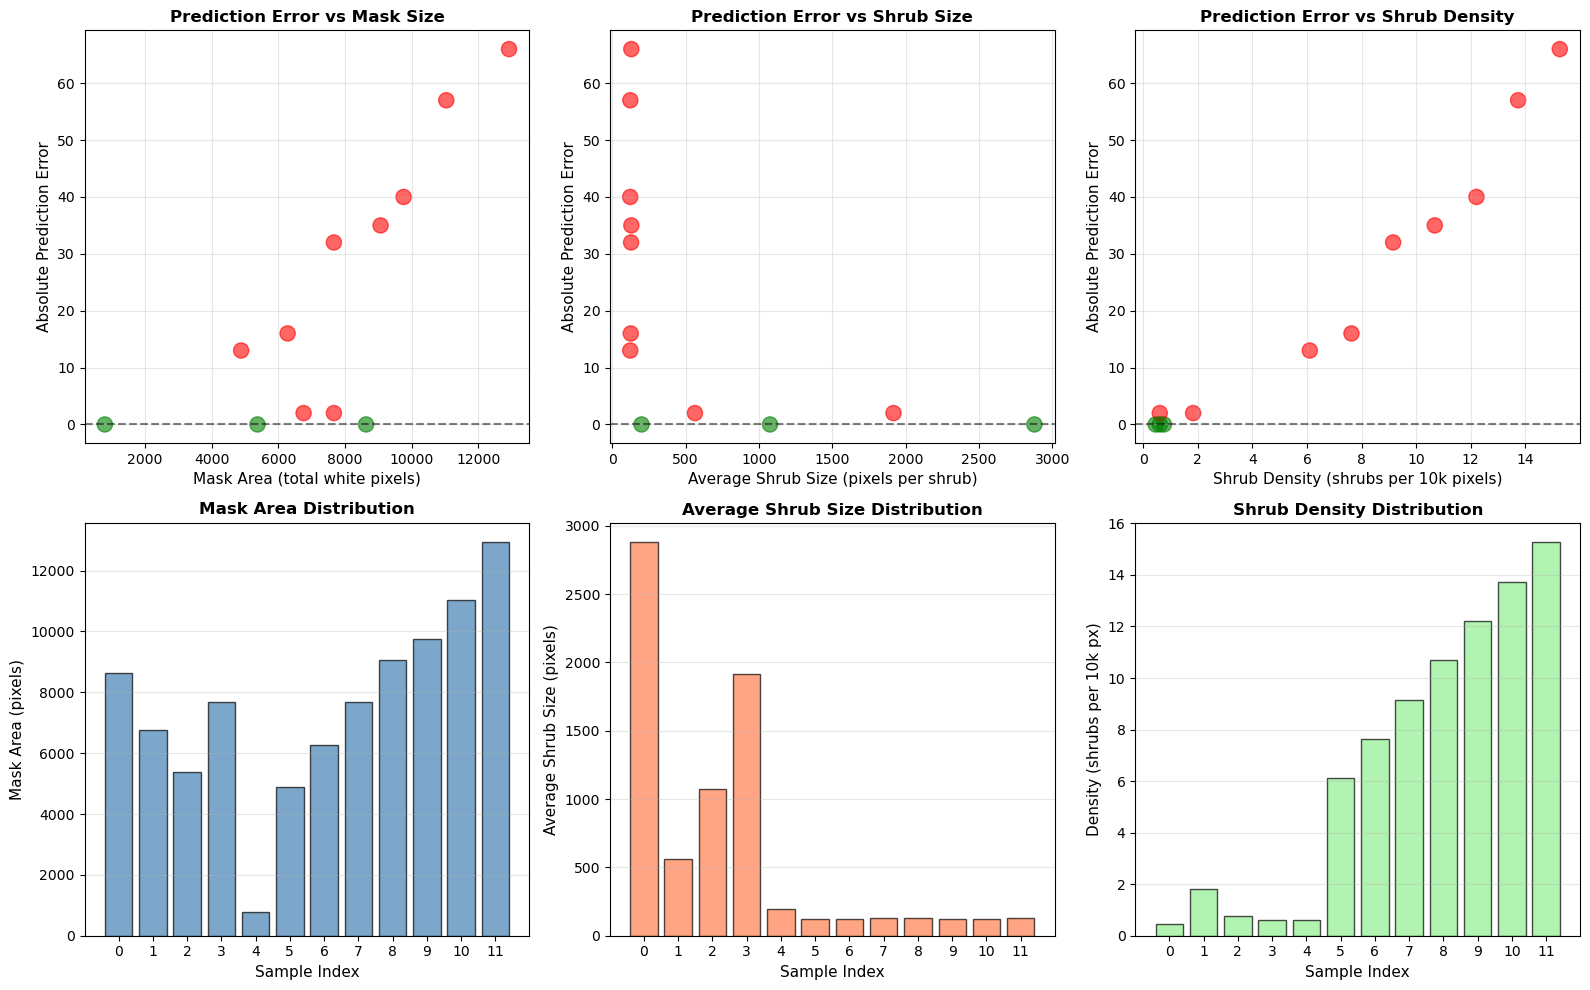


Sample   Area       Avg Size     Density      True   Pred   Error  
--------------------------------------------------------------------------------
1        8635       2878.3       0.4578       3      3           +0
2        6760       563.3        1.8311       12     10          -2
3        5377       1075.4       0.7629       5      5           +0
4        7669       1917.2       0.6104       4      2           -2
5        796        199.0        0.6104       4      4           +0
6        4885       122.1        6.1035       40     27         -13
7        6281       125.6        7.6294       50     34         -16
8        7669       127.8        9.1553       60     28         -32
9        9070       129.6        10.6812      70     35         -35
10       9761       122.0        12.2070      80     40         -40
11       11042      122.7        13.7329      90     33         -57
12       12925      129.2        15.2588      100    34         -66

✓ Image size analysis plot saved


In [11]:
# ============================================================================
# IMAGE SIZE AND SHRUB DENSITY ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("IMAGE SIZE AND SHRUB DENSITY ANALYSIS")
print("="*80)

# Calculate mask statistics for each sample
mask_stats = []
for idx, (mask, true_count, result) in enumerate(zip(sample_masks, true_counts, all_results)):
    # Mask area (total white pixels)
    mask_area = np.sum(mask > 0)
    
    # Average shrub size (area per shrub)
    avg_shrub_size = mask_area / true_count if true_count > 0 else 0
    
    # Density (shrubs per 256x256 image area)
    image_area = 256 * 256
    density = (true_count / image_area) * 10000  # shrubs per 10k pixels
    
    mask_stats.append({
        'sample': idx + 1,
        'mask_area': mask_area,
        'avg_shrub_size': avg_shrub_size,
        'density': density,
        'true_count': true_count,
        'predicted_count': result['predicted_count'],
        'error': result['error'],
        'abs_error': abs(result['error'])
    })

# Create plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Mask area vs prediction error
ax1 = axes[0, 0]
mask_areas = [s['mask_area'] for s in mask_stats]
abs_errors_plot = [s['abs_error'] for s in mask_stats]
colors_error = ['red' if s['error'] < 0 else 'green' for s in mask_stats]
ax1.scatter(mask_areas, abs_errors_plot, s=120, alpha=0.6, c=colors_error)
ax1.set_xlabel('Mask Area (total white pixels)', fontsize=11)
ax1.set_ylabel('Absolute Prediction Error', fontsize=11)
ax1.set_title('Prediction Error vs Mask Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Plot 2: Average shrub size vs prediction error
ax2 = axes[0, 1]
avg_shrub_sizes = [s['avg_shrub_size'] for s in mask_stats]
ax2.scatter(avg_shrub_sizes, abs_errors_plot, s=120, alpha=0.6, c=colors_error)
ax2.set_xlabel('Average Shrub Size (pixels per shrub)', fontsize=11)
ax2.set_ylabel('Absolute Prediction Error', fontsize=11)
ax2.set_title('Prediction Error vs Shrub Size', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Plot 3: Density vs prediction error
ax3 = axes[0, 2]
densities = [s['density'] for s in mask_stats]
ax3.scatter(densities, abs_errors_plot, s=120, alpha=0.6, c=colors_error)
ax3.set_xlabel('Shrub Density (shrubs per 10k pixels)', fontsize=11)
ax3.set_ylabel('Absolute Prediction Error', fontsize=11)
ax3.set_title('Prediction Error vs Shrub Density', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Plot 4: Mask area distribution
ax4 = axes[1, 0]
ax4.bar(range(len(mask_stats)), mask_areas, alpha=0.7, color='steelblue', edgecolor='black')
ax4.set_xlabel('Sample Index', fontsize=11)
ax4.set_ylabel('Mask Area (pixels)', fontsize=11)
ax4.set_title('Mask Area Distribution', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticks(range(len(mask_stats)))

# Plot 5: Average shrub size distribution
ax5 = axes[1, 1]
ax5.bar(range(len(mask_stats)), avg_shrub_sizes, alpha=0.7, color='coral', edgecolor='black')
ax5.set_xlabel('Sample Index', fontsize=11)
ax5.set_ylabel('Average Shrub Size (pixels)', fontsize=11)
ax5.set_title('Average Shrub Size Distribution', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_xticks(range(len(mask_stats)))

# Plot 6: Density distribution
ax6 = axes[1, 2]
ax6.bar(range(len(mask_stats)), densities, alpha=0.7, color='lightgreen', edgecolor='black')
ax6.set_xlabel('Sample Index', fontsize=11)
ax6.set_ylabel('Density (shrubs per 10k px)', fontsize=11)
ax6.set_title('Shrub Density Distribution', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_xticks(range(len(mask_stats)))

plt.tight_layout()
plt.savefig('image_size_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Print statistics table
print(f"\n{'Sample':<8} {'Area':<10} {'Avg Size':<12} {'Density':<12} {'True':<6} {'Pred':<6} {'Error':<7}")
print("-" * 80)
for s in mask_stats:
    print(f"{s['sample']:<8} {s['mask_area']:<10} {s['avg_shrub_size']:<12.1f} {s['density']:<12.4f} "
          f"{s['true_count']:<6} {s['predicted_count']:<6} {s['error']:+7}")

print("\n✓ Image size analysis plot saved")


WINDOW SIZE ANALYSIS: Testing 1000, 2000, 3000, 4000, 5000, 6000 pixels

Window Size: 31×31 (1000 pixels)
  Sample  5/20: True=1, Pred=1, Error= +0
  Sample 10/20: True=7, Pred=0, Error= -7
  Sample 15/20: True=5, Pred=1, Error= -4
  Sample 20/20: True=3, Pred=1, Error= -2

  MAE: 3.150 | Accuracy ±1: 30.0% | Accuracy ±2: 50.0%

Window Size: 44×44 (2000 pixels)
  Sample  5/20: True=2, Pred=1, Error= -1
  Sample 10/20: True=4, Pred=3, Error= -1
  Sample 15/20: True=7, Pred=2, Error= -5
  Sample 20/20: True=3, Pred=1, Error= -2

  MAE: 3.250 | Accuracy ±1: 40.0% | Accuracy ±2: 60.0%

Window Size: 54×54 (3000 pixels)
  Sample  5/20: True=5, Pred=3, Error= -2
  Sample 10/20: True=2, Pred=2, Error= +0
  Sample 15/20: True=8, Pred=2, Error= -6
  Sample 20/20: True=8, Pred=4, Error= -4

  MAE: 2.600 | Accuracy ±1: 40.0% | Accuracy ±2: 60.0%

Window Size: 63×63 (4000 pixels)
  Sample  5/20: True=6, Pred=4, Error= -2
  Sample 10/20: True=8, Pred=6, Error= -2
  Sample 15/20: True=1, Pred=1, Err

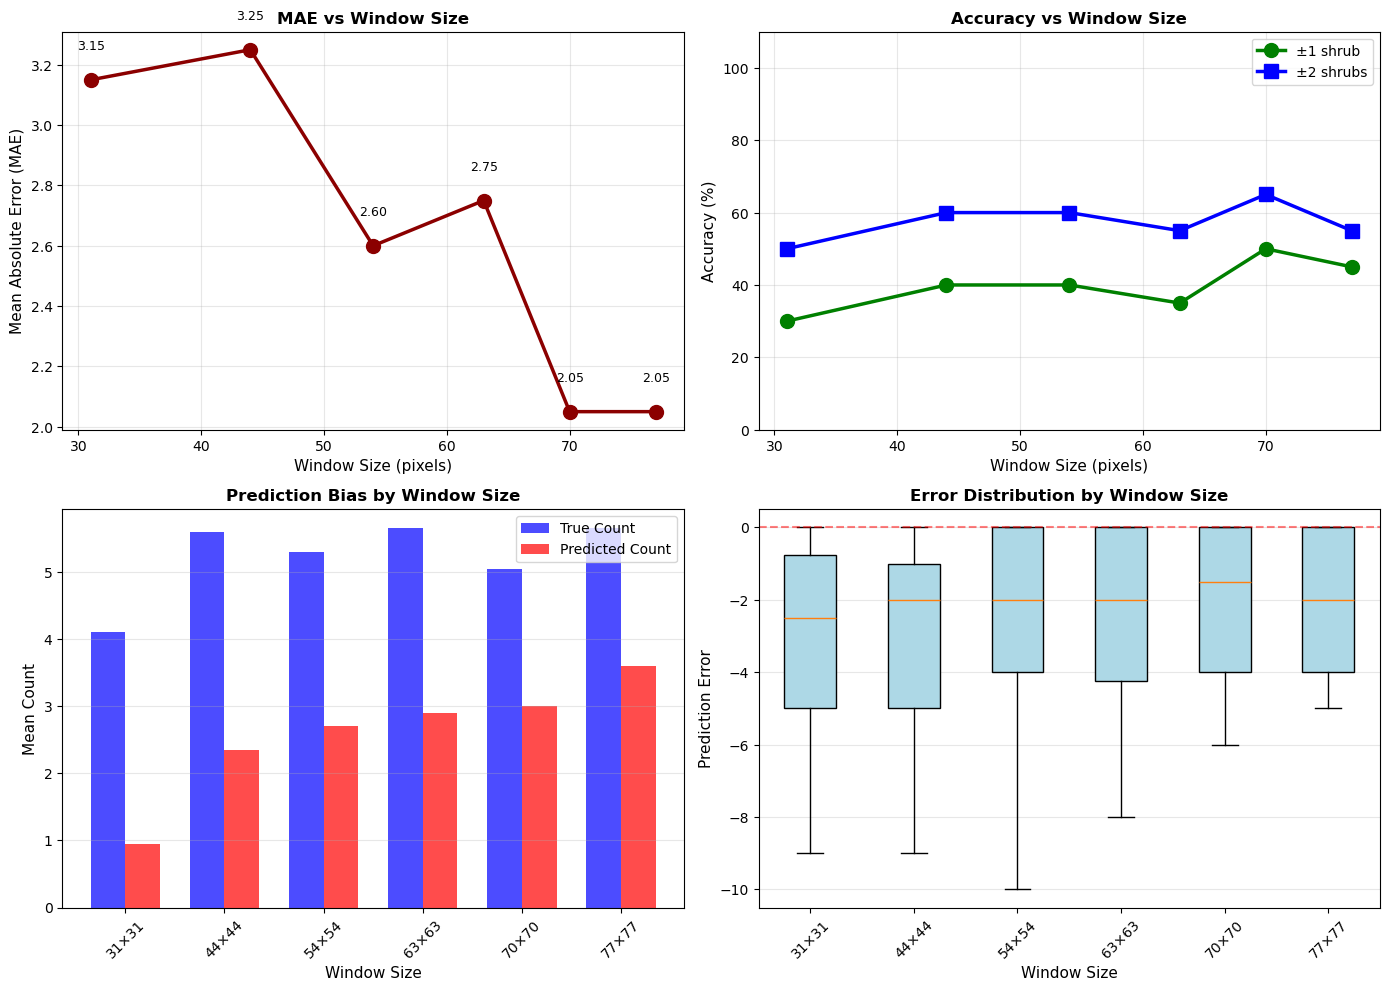


✓ Window size analysis complete!
  Total samples tested: 120
  Window sizes: [1000, 2000, 3000, 4000, 5000, 6000]


In [12]:
# ============================================================================
# WINDOW SIZE ANALYSIS: Test multiple window sizes with 20-25 samples each
# ============================================================================

print("\n" + "="*80)
print("WINDOW SIZE ANALYSIS: Testing 1000, 2000, 3000, 4000, 5000, 6000 pixels")
print("="*80)

window_pixel_areas = [1000, 2000, 3000, 4000, 5000, 6000]
samples_per_size = 20
window_results = []

np.random.seed(456)

for total_pixels in window_pixel_areas:
    # Calculate window dimensions (square)
    window_size = int(np.sqrt(total_pixels))
    print(f"\n{'='*80}")
    print(f"Window Size: {window_size}×{window_size} ({total_pixels} pixels)")
    print(f"{'='*80}")
    
    size_results = []
    
    for sample_num in range(samples_per_size):
        # Create random shrub mask for this window
        mask = np.zeros((window_size, window_size), dtype=np.uint8)
        
        # Random shrub count (1-10 shrubs for small windows)
        true_count = np.random.randint(1, min(11, window_size // 3))
        
        # Place shrubs at random positions with random sizes
        for _ in range(true_count):
            cx = np.random.randint(5, window_size - 5)
            cy = np.random.randint(5, window_size - 5)
            # Shrub radius scales with window size
            r = max(1, int(np.random.uniform(1, max(2, window_size // 10))))
            cv2.circle(mask, (cx, cy), r, 1, -1)
        
        # Get ensemble prediction
        predicted_count, _ = ensemble_predict_shrub_count(mask, verbose=False)
        
        # Calculate error
        error = predicted_count - true_count
        accuracy_1 = 1 if abs(error) <= 1 else 0
        accuracy_2 = 1 if abs(error) <= 2 else 0
        
        size_results.append({
            'window_size': window_size,
            'total_pixels': total_pixels,
            'sample_num': sample_num + 1,
            'true_count': true_count,
            'predicted_count': predicted_count,
            'error': error,
            'within_1': accuracy_1,
            'within_2': accuracy_2
        })
        
        if (sample_num + 1) % 5 == 0:
            print(f"  Sample {sample_num + 1:2d}/20: True={true_count}, Pred={predicted_count}, Error={error:+3d}")
    
    # Statistics for this window size
    errors_size = np.array([r['error'] for r in size_results])
    mae_size = np.mean(np.abs(errors_size))
    acc1_size = np.mean([r['within_1'] for r in size_results]) * 100
    acc2_size = np.mean([r['within_2'] for r in size_results]) * 100
    
    print(f"\n  MAE: {mae_size:.3f} | Accuracy ±1: {acc1_size:.1f}% | Accuracy ±2: {acc2_size:.1f}%")
    
    window_results.extend(size_results)

# Summary analysis by window size
print("\n" + "="*80)
print("WINDOW SIZE SUMMARY STATISTICS")
print("="*80)

window_summary = []
for total_pixels in window_pixel_areas:
    window_size = int(np.sqrt(total_pixels))
    size_data = [r for r in window_results if r['total_pixels'] == total_pixels]
    
    errors_size = np.array([r['error'] for r in size_data])
    mae_size = np.mean(np.abs(errors_size))
    acc1_size = np.mean([r['within_1'] for r in size_data]) * 100
    acc2_size = np.mean([r['within_2'] for r in size_data]) * 100
    mean_true = np.mean([r['true_count'] for r in size_data])
    mean_pred = np.mean([r['predicted_count'] for r in size_data])
    
    window_summary.append({
        'window_size': window_size,
        'total_pixels': total_pixels,
        'mae': mae_size,
        'acc1': acc1_size,
        'acc2': acc2_size,
        'mean_true': mean_true,
        'mean_pred': mean_pred,
        'samples': len(size_data)
    })

print(f"\n{'Window':<12} {'Pixels':<10} {'MAE':<10} {'Acc±1':<10} {'Acc±2':<10} {'Avg True':<10} {'Avg Pred':<10}")
print("-" * 80)
for summary in window_summary:
    print(f"{summary['window_size']}×{summary['window_size']:<6} {summary['total_pixels']:<10} "
          f"{summary['mae']:<10.3f} {summary['acc1']:<10.1f}% {summary['acc2']:<10.1f}% "
          f"{summary['mean_true']:<10.2f} {summary['mean_pred']:<10.2f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE vs window size
ax1 = axes[0, 0]
window_sizes_plot = [s['window_size'] for s in window_summary]
maes = [s['mae'] for s in window_summary]
ax1.plot(window_sizes_plot, maes, marker='o', linewidth=2.5, markersize=10, color='darkred')
ax1.set_xlabel('Window Size (pixels)', fontsize=11)
ax1.set_ylabel('Mean Absolute Error (MAE)', fontsize=11)
ax1.set_title('MAE vs Window Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
for i, (size, mae) in enumerate(zip(window_sizes_plot, maes)):
    ax1.text(size, mae + 0.1, f'{mae:.2f}', ha='center', fontsize=9)

# Plot 2: Accuracy vs window size
ax2 = axes[0, 1]
acc1_vals = [s['acc1'] for s in window_summary]
acc2_vals = [s['acc2'] for s in window_summary]
ax2.plot(window_sizes_plot, acc1_vals, marker='o', linewidth=2.5, markersize=10, label='±1 shrub', color='green')
ax2.plot(window_sizes_plot, acc2_vals, marker='s', linewidth=2.5, markersize=10, label='±2 shrubs', color='blue')
ax2.set_xlabel('Window Size (pixels)', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy vs Window Size', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 110])

# Plot 3: Prediction bias (mean predicted vs mean true)
ax3 = axes[1, 0]
mean_trues = [s['mean_true'] for s in window_summary]
mean_preds = [s['mean_pred'] for s in window_summary]
x_pos = np.arange(len(window_sizes_plot))
width = 0.35
ax3.bar(x_pos - width/2, mean_trues, width, label='True Count', alpha=0.7, color='blue')
ax3.bar(x_pos + width/2, mean_preds, width, label='Predicted Count', alpha=0.7, color='red')
ax3.set_xlabel('Window Size', fontsize=11)
ax3.set_ylabel('Mean Count', fontsize=11)
ax3.set_title('Prediction Bias by Window Size', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'{s}×{s}' for s in window_sizes_plot], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Error distribution by window size
ax4 = axes[1, 1]
all_errors_by_size = [np.array([r['error'] for r in window_results if r['total_pixels'] == tp]) 
                      for tp in window_pixel_areas]
bp = ax4.boxplot(all_errors_by_size, labels=[f'{s}×{s}' for s in window_sizes_plot], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax4.set_xlabel('Window Size', fontsize=11)
ax4.set_ylabel('Prediction Error', fontsize=11)
ax4.set_title('Error Distribution by Window Size', fontsize=12, fontweight='bold')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax4.grid(True, alpha=0.3, axis='y')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('window_size_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Window size analysis complete!")
print(f"  Total samples tested: {len(window_results)}")
print(f"  Window sizes: {window_pixel_areas}")



FINE-GRAINED WINDOW SIZE ANALYSIS: 10×10 to 100×100 pixels (40-50 samples each)

Testing 10×10 windows...
  MAE: 0.000 | Accuracy ±1: 100.0% | Accuracy ±2: 100.0% | Avg True: 0.40

Testing 20×20 windows...
  MAE: 0.000 | Accuracy ±1: 100.0% | Accuracy ±2: 100.0% | Avg True: 0.56

Testing 30×30 windows...
  MAE: 0.222 | Accuracy ±1: 100.0% | Accuracy ±2: 100.0% | Avg True: 1.11

Testing 40×40 windows...
  MAE: 0.156 | Accuracy ±1: 100.0% | Accuracy ±2: 100.0% | Avg True: 0.91

Testing 50×50 windows...
  MAE: 0.289 | Accuracy ±1: 97.8% | Accuracy ±2: 100.0% | Avg True: 1.44

Testing 60×60 windows...
  MAE: 0.289 | Accuracy ±1: 95.6% | Accuracy ±2: 100.0% | Avg True: 1.84

Testing 70×70 windows...
  MAE: 0.244 | Accuracy ±1: 95.6% | Accuracy ±2: 100.0% | Avg True: 1.91

Testing 80×80 windows...
  MAE: 0.667 | Accuracy ±1: 77.8% | Accuracy ±2: 100.0% | Avg True: 2.64

Testing 90×90 windows...
  MAE: 0.756 | Accuracy ±1: 82.2% | Accuracy ±2: 91.1% | Avg True: 2.64

Testing 100×100 windows.

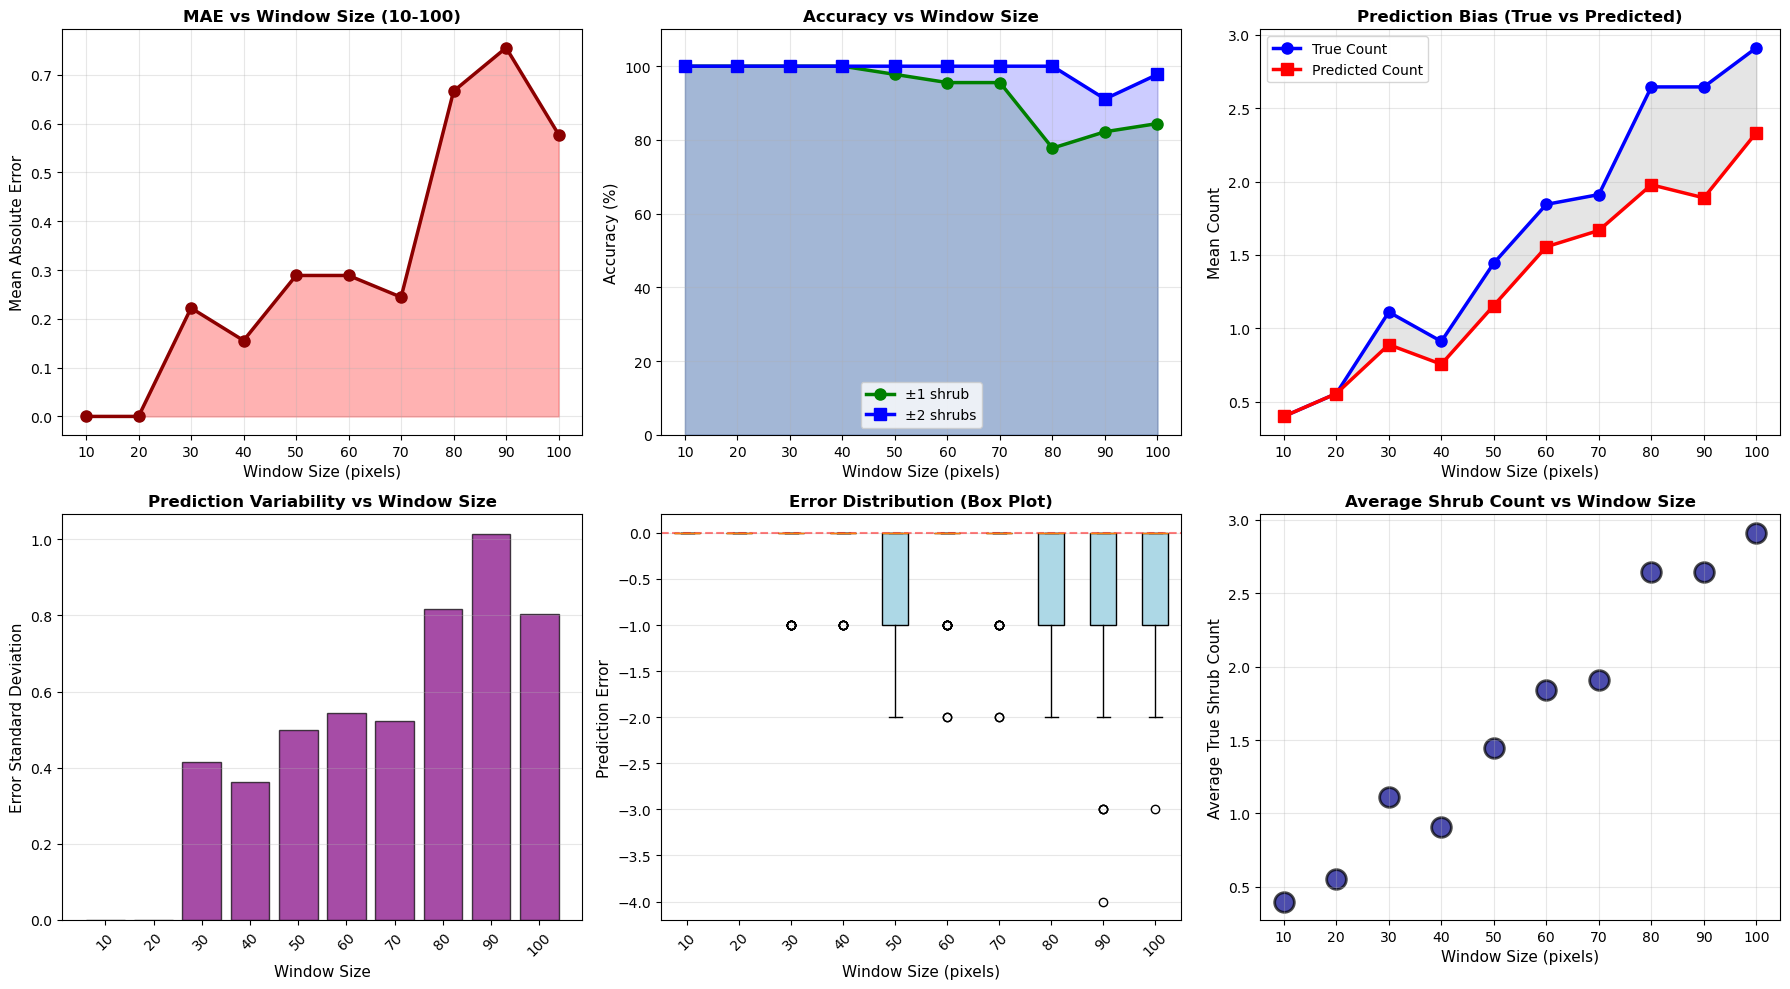


✓ Fine-grained window size analysis complete!
  Total samples tested: 450
  Window sizes: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
  Samples per size: 45


In [13]:
# ============================================================================
# FINE-GRAINED WINDOW SIZE ANALYSIS: 10×10 to 100×100 with 40-50 samples each
# ============================================================================

print("\n" + "="*80)
print("FINE-GRAINED WINDOW SIZE ANALYSIS: 10×10 to 100×100 pixels (40-50 samples each)")
print("="*80)

window_sizes_fine = list(range(10, 101, 10))  # 10, 20, 30, ..., 100
samples_per_fine = 45
fine_window_results = []

np.random.seed(789)

for window_size in window_sizes_fine:
    print(f"\nTesting {window_size}×{window_size} windows...")
    size_results = []
    
    for sample_num in range(samples_per_fine):
        # Create random shrub mask for this window
        mask = np.zeros((window_size, window_size), dtype=np.uint8)
        
        # Determine max shrubs based on window size (roughly 0.1-1 shrub per 100 pixels)
        max_shrubs = max(1, window_size // 15)
        true_count = np.random.randint(0, max_shrubs + 1)
        
        # Place shrubs at random positions
        for _ in range(true_count):
            if window_size > 10:
                cx = np.random.randint(2, window_size - 2)
                cy = np.random.randint(2, window_size - 2)
            else:
                cx = np.random.randint(1, window_size - 1) if window_size > 2 else window_size // 2
                cy = np.random.randint(1, window_size - 1) if window_size > 2 else window_size // 2
            
            # Shrub radius scales with window size (1-3 pixels for small, up to 5-10 for large)
            r = max(1, int(np.random.uniform(1, max(2, window_size // 8))))
            cv2.circle(mask, (cx, cy), r, 1, -1)
        
        # Get ensemble prediction
        predicted_count, _ = ensemble_predict_shrub_count(mask, verbose=False)
        
        # Calculate error
        error = predicted_count - true_count
        accuracy_1 = 1 if abs(error) <= 1 else 0
        accuracy_2 = 1 if abs(error) <= 2 else 0
        
        size_results.append({
            'window_size': window_size,
            'sample_num': sample_num + 1,
            'true_count': true_count,
            'predicted_count': predicted_count,
            'error': error,
            'within_1': accuracy_1,
            'within_2': accuracy_2
        })
    
    # Statistics for this window size
    errors_size = np.array([r['error'] for r in size_results])
    mae_size = np.mean(np.abs(errors_size))
    acc1_size = np.mean([r['within_1'] for r in size_results]) * 100
    acc2_size = np.mean([r['within_2'] for r in size_results]) * 100
    
    print(f"  MAE: {mae_size:.3f} | Accuracy ±1: {acc1_size:.1f}% | Accuracy ±2: {acc2_size:.1f}% | "
          f"Avg True: {np.mean([r['true_count'] for r in size_results]):.2f}")
    
    fine_window_results.extend(size_results)

# Summary analysis by window size
print("\n" + "="*80)
print("FINE-GRAINED WINDOW SIZE SUMMARY STATISTICS")
print("="*80)

fine_summary = []
for window_size in window_sizes_fine:
    size_data = [r for r in fine_window_results if r['window_size'] == window_size]
    
    errors_size = np.array([r['error'] for r in size_data])
    mae_size = np.mean(np.abs(errors_size))
    acc1_size = np.mean([r['within_1'] for r in size_data]) * 100
    acc2_size = np.mean([r['within_2'] for r in size_data]) * 100
    mean_true = np.mean([r['true_count'] for r in size_data])
    mean_pred = np.mean([r['predicted_count'] for r in size_data])
    std_error = np.std(errors_size)
    
    fine_summary.append({
        'window_size': window_size,
        'mae': mae_size,
        'acc1': acc1_size,
        'acc2': acc2_size,
        'mean_true': mean_true,
        'mean_pred': mean_pred,
        'std_error': std_error,
        'samples': len(size_data)
    })

print(f"\n{'Window':<10} {'MAE':<10} {'Acc±1':<10} {'Acc±2':<10} {'AvgTrue':<10} {'AvgPred':<10} {'StdErr':<10}")
print("-" * 80)
for summary in fine_summary:
    print(f"{summary['window_size']:>3d}×{summary['window_size']:<5d} {summary['mae']:<10.3f} "
          f"{summary['acc1']:<10.1f}% {summary['acc2']:<10.1f}% {summary['mean_true']:<10.2f} "
          f"{summary['mean_pred']:<10.2f} {summary['std_error']:<10.3f}")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: MAE vs window size (line plot)
ax1 = axes[0, 0]
maes_fine = [s['mae'] for s in fine_summary]
ax1.plot(window_sizes_fine, maes_fine, marker='o', linewidth=2.5, markersize=8, color='darkred')
ax1.fill_between(window_sizes_fine, maes_fine, alpha=0.3, color='red')
ax1.set_xlabel('Window Size (pixels)', fontsize=11)
ax1.set_ylabel('Mean Absolute Error', fontsize=11)
ax1.set_title('MAE vs Window Size (10-100)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(window_sizes_fine)

# Plot 2: Accuracy vs window size
ax2 = axes[0, 1]
acc1_fine = [s['acc1'] for s in fine_summary]
acc2_fine = [s['acc2'] for s in fine_summary]
ax2.plot(window_sizes_fine, acc1_fine, marker='o', linewidth=2.5, markersize=8, label='±1 shrub', color='green')
ax2.plot(window_sizes_fine, acc2_fine, marker='s', linewidth=2.5, markersize=8, label='±2 shrubs', color='blue')
ax2.fill_between(window_sizes_fine, acc1_fine, alpha=0.2, color='green')
ax2.fill_between(window_sizes_fine, acc2_fine, alpha=0.2, color='blue')
ax2.set_xlabel('Window Size (pixels)', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy vs Window Size', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(window_sizes_fine)
ax2.set_ylim([0, 110])

# Plot 3: Prediction bias
ax3 = axes[0, 2]
mean_trues_fine = [s['mean_true'] for s in fine_summary]
mean_preds_fine = [s['mean_pred'] for s in fine_summary]
ax3.plot(window_sizes_fine, mean_trues_fine, marker='o', linewidth=2.5, markersize=8, label='True Count', color='blue')
ax3.plot(window_sizes_fine, mean_preds_fine, marker='s', linewidth=2.5, markersize=8, label='Predicted Count', color='red')
ax3.fill_between(window_sizes_fine, mean_trues_fine, mean_preds_fine, alpha=0.2, color='gray')
ax3.set_xlabel('Window Size (pixels)', fontsize=11)
ax3.set_ylabel('Mean Count', fontsize=11)
ax3.set_title('Prediction Bias (True vs Predicted)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(window_sizes_fine)

# Plot 4: Error variability (standard deviation)
ax4 = axes[1, 0]
std_errors = [s['std_error'] for s in fine_summary]
ax4.bar(range(len(window_sizes_fine)), std_errors, alpha=0.7, color='purple', edgecolor='black')
ax4.set_xlabel('Window Size', fontsize=11)
ax4.set_ylabel('Error Standard Deviation', fontsize=11)
ax4.set_title('Prediction Variability vs Window Size', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(window_sizes_fine)))
ax4.set_xticklabels([f'{s}' for s in window_sizes_fine], rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Box plot of errors
ax5 = axes[1, 1]
all_errors_by_fine = [np.array([r['error'] for r in fine_window_results if r['window_size'] == ws]) 
                      for ws in window_sizes_fine]
bp = ax5.boxplot(all_errors_by_fine, labels=[f'{s}' for s in window_sizes_fine], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax5.set_xlabel('Window Size (pixels)', fontsize=11)
ax5.set_ylabel('Prediction Error', fontsize=11)
ax5.set_title('Error Distribution (Box Plot)', fontsize=12, fontweight='bold')
ax5.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax5.grid(True, alpha=0.3, axis='y')
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)

# Plot 6: Sample count and true count distribution
ax6 = axes[1, 2]
avg_true_counts = [s['mean_true'] for s in fine_summary]
ax6.scatter(window_sizes_fine, avg_true_counts, s=200, alpha=0.7, color='darkblue', edgecolor='black', linewidth=2)
ax6.set_xlabel('Window Size (pixels)', fontsize=11)
ax6.set_ylabel('Average True Shrub Count', fontsize=11)
ax6.set_title('Average Shrub Count vs Window Size', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.set_xticks(window_sizes_fine)

plt.tight_layout()
plt.savefig('fine_window_size_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Fine-grained window size analysis complete!")
print(f"  Total samples tested: {len(fine_window_results)}")
print(f"  Window sizes: {window_sizes_fine}")
print(f"  Samples per size: {samples_per_fine}")



RECTANGULAR WINDOW ANALYSIS: Testing aspect ratios (1:1 to 5:1)

Testing 50×50 windows (1:1 (Square), 2500 pixels)...
  MAE: 1.467 | Accuracy ±1: 56.7% | Accuracy ±2: 73.3% | Avg True: 4.30

Testing 40×62 windows (1:1.5, 2480 pixels)...
  MAE: 1.300 | Accuracy ±1: 63.3% | Accuracy ±2: 76.7% | Avg True: 3.77

Testing 35×71 windows (1:2, 2485 pixels)...
  MAE: 1.067 | Accuracy ±1: 63.3% | Accuracy ±2: 86.7% | Avg True: 3.57

Testing 25×100 windows (1:4, 2500 pixels)...
  MAE: 1.133 | Accuracy ±1: 56.7% | Accuracy ±2: 83.3% | Avg True: 4.33

Testing 20×125 windows (1:6.25, 2500 pixels)...
  MAE: 0.633 | Accuracy ±1: 80.0% | Accuracy ±2: 93.3% | Avg True: 3.97

RECTANGULAR WINDOW SUMMARY STATISTICS

Aspect Ratio         Dims            Pixels     MAE        Acc±1      Acc±2      AvgTrue   
------------------------------------------------------------------------------------------
1:1 (Square)         50×50           2500       1.467      56.7      % 73.3      % 4.30      
1:1.5            

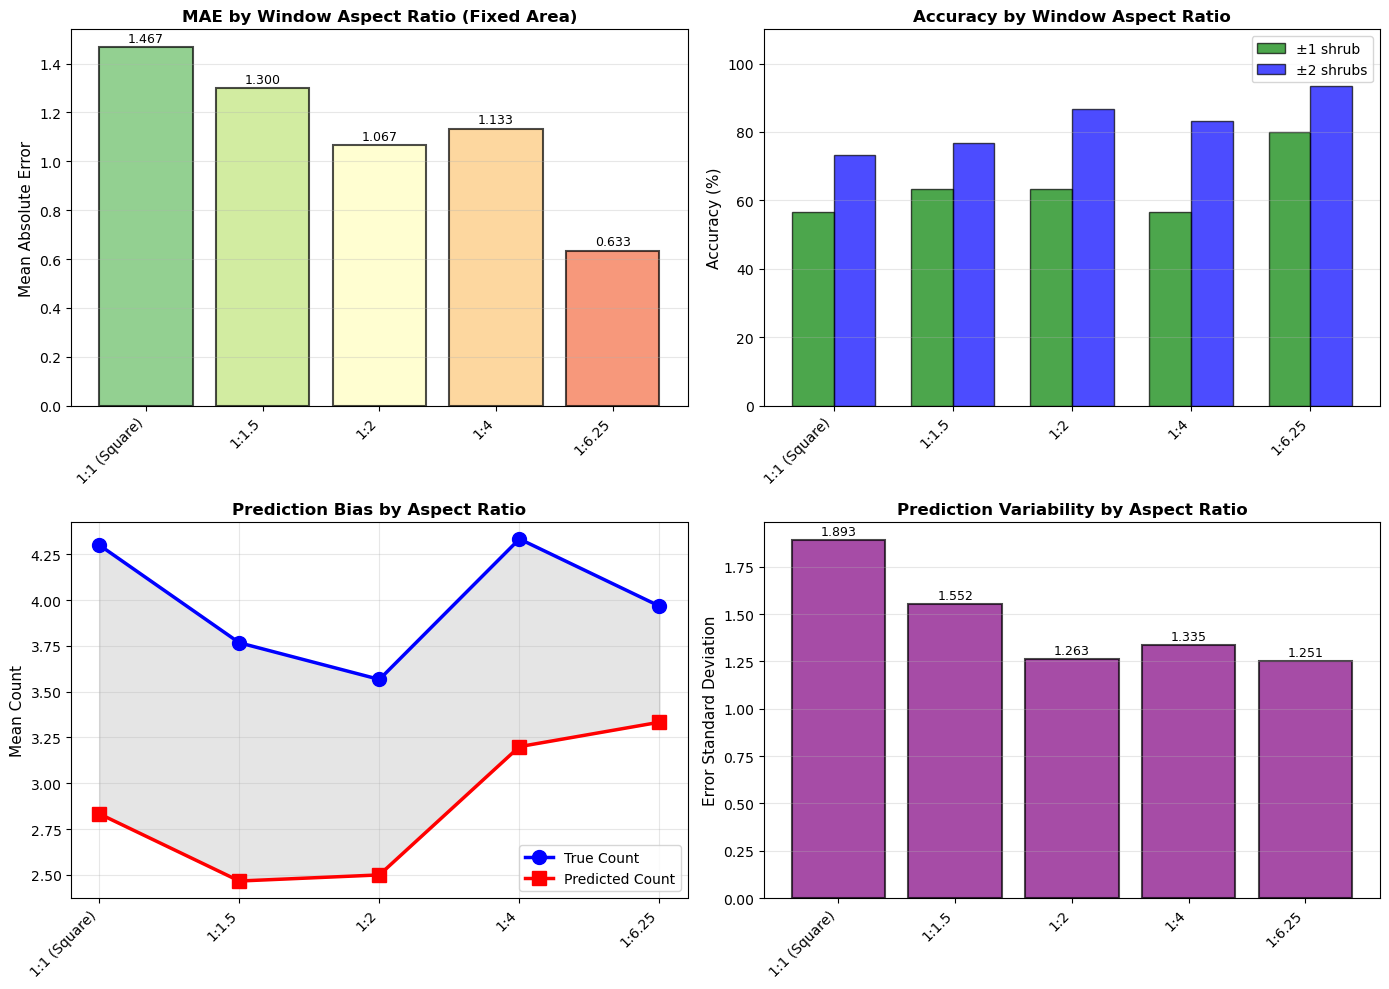


✓ Rectangular window analysis complete!
  Total samples tested: 150
  Aspect ratios tested: 5
  Samples per ratio: 30
  Target pixel area: 2500 pixels


In [14]:
# ============================================================================
# RECTANGULAR WINDOW ANALYSIS: Test aspect ratios with constant pixel area
# ============================================================================

print("\n" + "="*80)
print("RECTANGULAR WINDOW ANALYSIS: Testing aspect ratios (1:1 to 5:1)")
print("="*80)

# Test with a fixed pixel area (e.g., 2500 pixels)
target_pixels = 2500
samples_per_aspect = 30

# Define aspect ratios and corresponding dimensions
aspect_ratios = [
    (50, 50, "1:1 (Square)"),
    (40, 62, "1:1.5"),
    (35, 71, "1:2"),
    (25, 100, "1:4"),
    (20, 125, "1:6.25"),
]

rectangle_results = []

np.random.seed(321)

for height, width, label in aspect_ratios:
    print(f"\nTesting {height}×{width} windows ({label}, {height*width} pixels)...")
    aspect_results = []
    
    for sample_num in range(samples_per_aspect):
        # Create rectangular shrub mask
        mask = np.zeros((height, width), dtype=np.uint8)
        
        # Determine shrub count based on area
        max_shrubs = max(1, (height * width) // 300)
        true_count = np.random.randint(0, max_shrubs + 1)
        
        # Place shrubs randomly
        for _ in range(true_count):
            cy = np.random.randint(2, height - 2) if height > 4 else height // 2
            cx = np.random.randint(2, width - 2) if width > 4 else width // 2
            
            # Scale radius to window dimensions
            r = max(1, int(np.random.uniform(1, max(2, min(height, width) // 10))))
            cv2.circle(mask, (cx, cy), r, 1, -1)
        
        # Get ensemble prediction
        predicted_count, _ = ensemble_predict_shrub_count(mask, verbose=False)
        
        # Calculate error
        error = predicted_count - true_count
        accuracy_1 = 1 if abs(error) <= 1 else 0
        accuracy_2 = 1 if abs(error) <= 2 else 0
        
        aspect_results.append({
            'height': height,
            'width': width,
            'aspect_label': label,
            'total_pixels': height * width,
            'sample_num': sample_num + 1,
            'true_count': true_count,
            'predicted_count': predicted_count,
            'error': error,
            'within_1': accuracy_1,
            'within_2': accuracy_2
        })
    
    # Statistics for this aspect ratio
    errors_aspect = np.array([r['error'] for r in aspect_results])
    mae_aspect = np.mean(np.abs(errors_aspect))
    acc1_aspect = np.mean([r['within_1'] for r in aspect_results]) * 100
    acc2_aspect = np.mean([r['within_2'] for r in aspect_results]) * 100
    
    print(f"  MAE: {mae_aspect:.3f} | Accuracy ±1: {acc1_aspect:.1f}% | "
          f"Accuracy ±2: {acc2_aspect:.1f}% | Avg True: {np.mean([r['true_count'] for r in aspect_results]):.2f}")
    
    rectangle_results.extend(aspect_results)

# Summary analysis by aspect ratio
print("\n" + "="*80)
print("RECTANGULAR WINDOW SUMMARY STATISTICS")
print("="*80)

rectangle_summary = []
for height, width, label in aspect_ratios:
    aspect_data = [r for r in rectangle_results if r['height'] == height and r['width'] == width]
    
    errors_aspect = np.array([r['error'] for r in aspect_data])
    mae_aspect = np.mean(np.abs(errors_aspect))
    acc1_aspect = np.mean([r['within_1'] for r in aspect_data]) * 100
    acc2_aspect = np.mean([r['within_2'] for r in aspect_data]) * 100
    mean_true = np.mean([r['true_count'] for r in aspect_data])
    mean_pred = np.mean([r['predicted_count'] for r in aspect_data])
    std_error = np.std(errors_aspect)
    
    rectangle_summary.append({
        'height': height,
        'width': width,
        'aspect_label': label,
        'total_pixels': height * width,
        'mae': mae_aspect,
        'acc1': acc1_aspect,
        'acc2': acc2_aspect,
        'mean_true': mean_true,
        'mean_pred': mean_pred,
        'std_error': std_error,
        'samples': len(aspect_data)
    })

print(f"\n{'Aspect Ratio':<20} {'Dims':<15} {'Pixels':<10} {'MAE':<10} {'Acc±1':<10} {'Acc±2':<10} {'AvgTrue':<10}")
print("-" * 90)
for summary in rectangle_summary:
    dims_str = f"{summary['height']}×{summary['width']}"
    print(f"{summary['aspect_label']:<20} {dims_str:<15} {summary['total_pixels']:<10} "
          f"{summary['mae']:<10.3f} {summary['acc1']:<10.1f}% {summary['acc2']:<10.1f}% "
          f"{summary['mean_true']:<10.2f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

aspect_labels = [s['aspect_label'] for s in rectangle_summary]

# Plot 1: MAE vs aspect ratio
ax1 = axes[0, 0]
maes_rect = [s['mae'] for s in rectangle_summary]
colors_rect = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rectangle_summary)))
bars1 = ax1.bar(range(len(rectangle_summary)), maes_rect, alpha=0.7, color=colors_rect, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean Absolute Error', fontsize=11)
ax1.set_title('MAE by Window Aspect Ratio (Fixed Area)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(rectangle_summary)))
ax1.set_xticklabels(aspect_labels, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
for i, (bar, mae) in enumerate(zip(bars1, maes_rect)):
    ax1.text(i, mae + 0.01, f'{mae:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Accuracy vs aspect ratio
ax2 = axes[0, 1]
acc1_rect = [s['acc1'] for s in rectangle_summary]
acc2_rect = [s['acc2'] for s in rectangle_summary]
x_pos = np.arange(len(rectangle_summary))
width_bar = 0.35
ax2.bar(x_pos - width_bar/2, acc1_rect, width_bar, label='±1 shrub', alpha=0.7, color='green', edgecolor='black')
ax2.bar(x_pos + width_bar/2, acc2_rect, width_bar, label='±2 shrubs', alpha=0.7, color='blue', edgecolor='black')
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy by Window Aspect Ratio', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(aspect_labels, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim([0, 110])
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Prediction bias
ax3 = axes[1, 0]
mean_trues_rect = [s['mean_true'] for s in rectangle_summary]
mean_preds_rect = [s['mean_pred'] for s in rectangle_summary]
ax3.plot(range(len(rectangle_summary)), mean_trues_rect, marker='o', linewidth=2.5, markersize=10, 
         label='True Count', color='blue')
ax3.plot(range(len(rectangle_summary)), mean_preds_rect, marker='s', linewidth=2.5, markersize=10, 
         label='Predicted Count', color='red')
ax3.fill_between(range(len(rectangle_summary)), mean_trues_rect, mean_preds_rect, alpha=0.2, color='gray')
ax3.set_ylabel('Mean Count', fontsize=11)
ax3.set_title('Prediction Bias by Aspect Ratio', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(rectangle_summary)))
ax3.set_xticklabels(aspect_labels, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Error variability
ax4 = axes[1, 1]
std_errors_rect = [s['std_error'] for s in rectangle_summary]
bars4 = ax4.bar(range(len(rectangle_summary)), std_errors_rect, alpha=0.7, color='purple', edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Error Standard Deviation', fontsize=11)
ax4.set_title('Prediction Variability by Aspect Ratio', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(rectangle_summary)))
ax4.set_xticklabels(aspect_labels, rotation=45, ha='right')
ax4.grid(True, alpha=0.3, axis='y')
for i, (bar, std) in enumerate(zip(bars4, std_errors_rect)):
    ax4.text(i, std + 0.01, f'{std:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('rectangular_window_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Rectangular window analysis complete!")
print(f"  Total samples tested: {len(rectangle_results)}")
print(f"  Aspect ratios tested: {len(rectangle_summary)}")
print(f"  Samples per ratio: {samples_per_aspect}")
print(f"  Target pixel area: {target_pixels} pixels")



BALANCED SHRUB SIZING ANALYSIS: Accounting for image and shrub count

Testing Tiny (10×10, 1-2 shrubs)...
  MAE: 0.525 | MAPE: 26.2% | Acc±1: 100.0% | Acc±2: 100.0%

Testing Small (20×20, 2-4 shrubs)...
  MAE: 1.675 | MAPE: 49.0% | Acc±1: 55.0% | Acc±2: 70.0%

Testing Medium (50×50, 4-8 shrubs)...
  MAE: 1.825 | MAPE: 31.2% | Acc±1: 50.0% | Acc±2: 72.5%

Testing Large (100×100, 8-15 shrubs)...
  MAE: 1.725 | MAPE: 17.6% | Acc±1: 62.5% | Acc±2: 72.5%

Testing Wide Rectangle (50×150, 5-10 shrubs)...
  MAE: 1.375 | MAPE: 19.3% | Acc±1: 57.5% | Acc±2: 82.5%

Testing Tall Rectangle (150×50, 5-10 shrubs)...
  MAE: 1.025 | MAPE: 14.6% | Acc±1: 65.0% | Acc±2: 90.0%

BALANCED SIZING SUMMARY STATISTICS

Configuration                       MAE        MAPE       Acc±1      Acc±2     
-----------------------------------------------------------------------------------------------
Tiny (10×10, 1-2 shrubs)            0.525      26.2      % 100.0     % 100.0     %
Small (20×20, 2-4 shrubs)           1

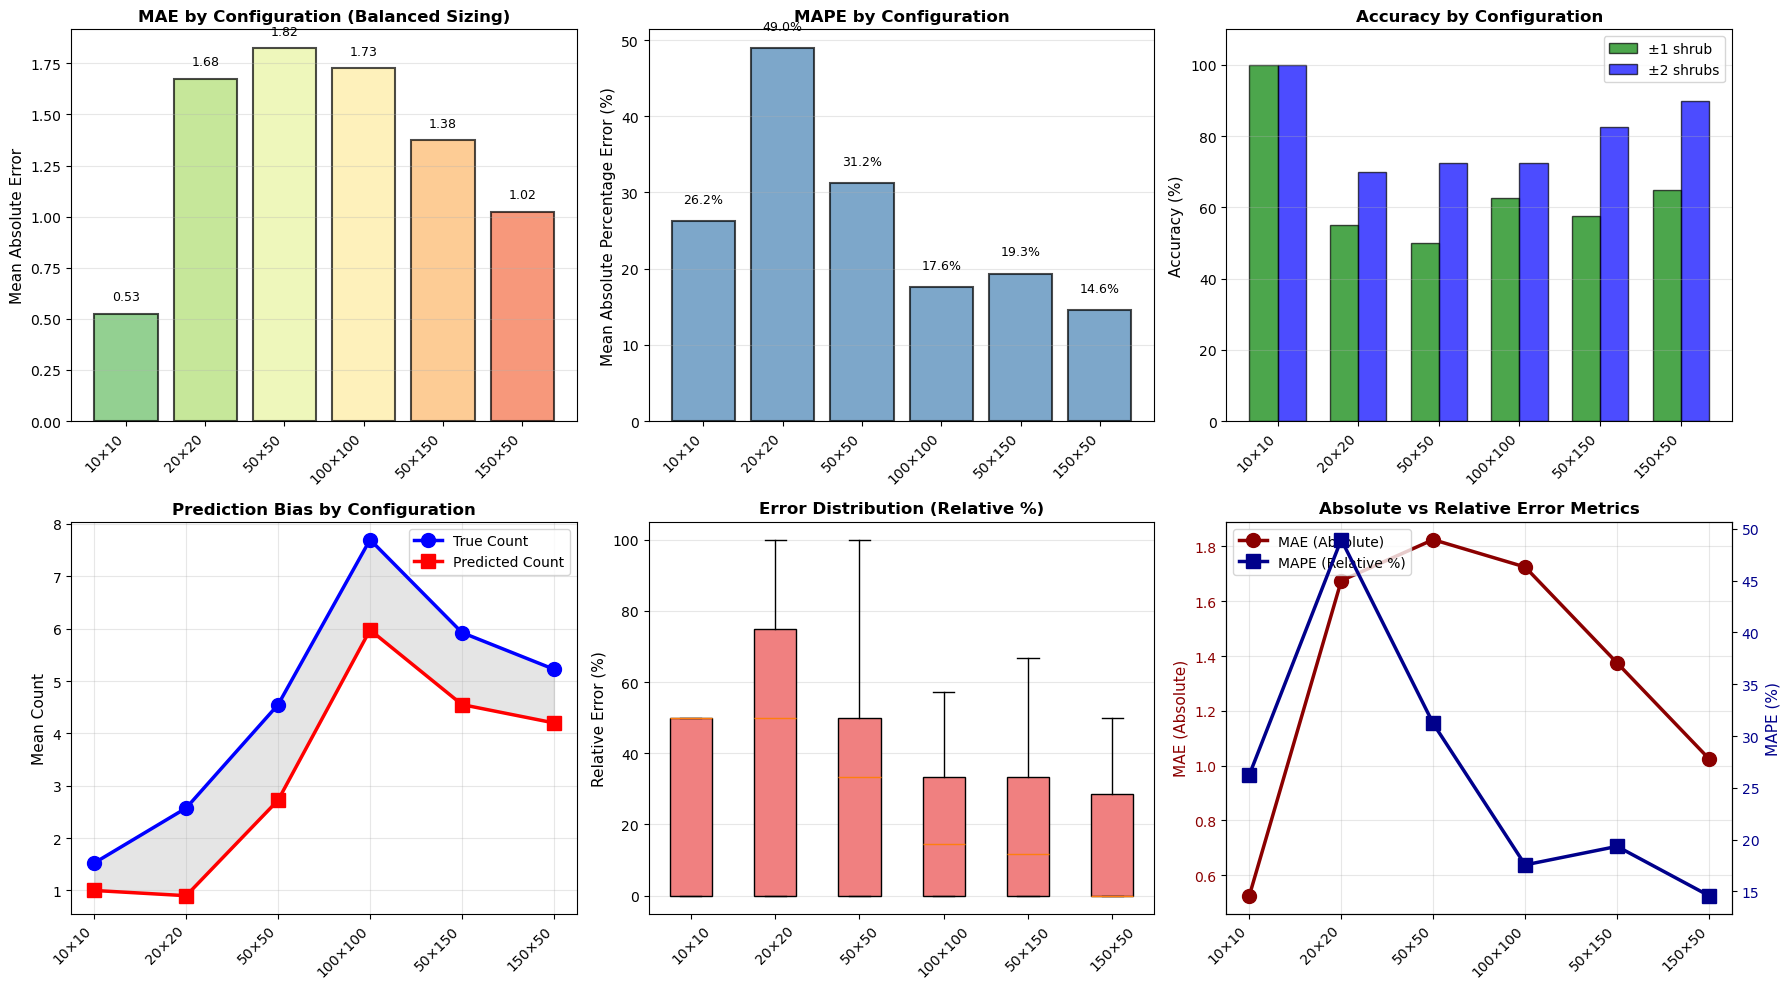


✓ Balanced shrub sizing analysis complete!
  Total samples tested: 240
  Configurations: 6
  Key insight: MAPE provides better fairness across different shrub counts


In [15]:
# ============================================================================
# BALANCED SHRUB SIZING: Adjusted for image size and shrub count
# ============================================================================

print("\n" + "="*80)
print("BALANCED SHRUB SIZING ANALYSIS: Accounting for image and shrub count")
print("="*80)

def calculate_shrub_radius(image_height, image_width, shrub_count):
    """
    Calculate appropriate shrub radius based on image size and shrub count.
    Smaller shrubs in dense scenes, larger in sparse scenes.
    Scales with sqrt(area / count) to maintain realistic density.
    """
    if shrub_count == 0:
        return 1
    
    image_area = image_height * image_width
    area_per_shrub = image_area / max(1, shrub_count)
    
    # Base radius scales with sqrt(area_per_shrub)
    base_radius = max(1, int(np.sqrt(area_per_shrub) / 8))
    
    # Add slight randomness (±20%)
    radius = max(1, int(base_radius * np.random.uniform(0.8, 1.2)))
    
    return radius

# Test window configurations with balanced shrub sizing
test_configs = [
    ("Tiny (10×10, 1-2 shrubs)", 10, 10, 2),
    ("Small (20×20, 2-4 shrubs)", 20, 20, 4),
    ("Medium (50×50, 4-8 shrubs)", 50, 50, 8),
    ("Large (100×100, 8-15 shrubs)", 100, 100, 15),
    ("Wide Rectangle (50×150, 5-10 shrubs)", 50, 150, 10),
    ("Tall Rectangle (150×50, 5-10 shrubs)", 150, 50, 10),
]

balanced_results = []
np.random.seed(654)

for config_name, height, width, max_shrubs in test_configs:
    print(f"\nTesting {config_name}...")
    config_results = []
    
    for sample_num in range(40):
        # Create mask
        mask = np.zeros((height, width), dtype=np.uint8)
        
        # Random shrub count
        true_count = np.random.randint(1, max_shrubs + 1)
        
        # Place shrubs with balanced sizing
        for _ in range(true_count):
            cy = np.random.randint(2, max(3, height - 2))
            cx = np.random.randint(2, max(3, width - 2))
            
            # Balanced radius based on image size and shrub count
            r = calculate_shrub_radius(height, width, true_count)
            cv2.circle(mask, (cx, cy), r, 1, -1)
        
        # Get ensemble prediction
        predicted_count, _ = ensemble_predict_shrub_count(mask, verbose=False)
        
        # Calculate errors
        abs_error = abs(predicted_count - true_count)
        rel_error = abs_error / max(1, true_count)  # Relative error
        
        accuracy_1 = 1 if abs_error <= 1 else 0
        accuracy_2 = 1 if abs_error <= 2 else 0
        
        config_results.append({
            'config_name': config_name,
            'height': height,
            'width': width,
            'true_count': true_count,
            'predicted_count': predicted_count,
            'abs_error': abs_error,
            'rel_error': rel_error,
            'within_1': accuracy_1,
            'within_2': accuracy_2
        })
    
    # Statistics for this configuration
    abs_errors = np.array([r['abs_error'] for r in config_results])
    rel_errors = np.array([r['rel_error'] for r in config_results])
    mae = np.mean(abs_errors)
    mape = np.mean(rel_errors) * 100  # Mean Absolute Percentage Error
    acc1 = np.mean([r['within_1'] for r in config_results]) * 100
    acc2 = np.mean([r['within_2'] for r in config_results]) * 100
    
    print(f"  MAE: {mae:.3f} | MAPE: {mape:.1f}% | Acc±1: {acc1:.1f}% | Acc±2: {acc2:.1f}%")
    
    balanced_results.extend(config_results)

# Summary
print("\n" + "="*80)
print("BALANCED SIZING SUMMARY STATISTICS")
print("="*80)

balanced_summary = []
for config_name, height, width, max_shrubs in test_configs:
    config_data = [r for r in balanced_results if r['config_name'] == config_name]
    
    abs_errors = np.array([r['abs_error'] for r in config_data])
    rel_errors = np.array([r['rel_error'] for r in config_data])
    
    mae = np.mean(abs_errors)
    mape = np.mean(rel_errors) * 100
    acc1 = np.mean([r['within_1'] for r in config_data]) * 100
    acc2 = np.mean([r['within_2'] for r in config_data]) * 100
    mean_true = np.mean([r['true_count'] for r in config_data])
    mean_pred = np.mean([r['predicted_count'] for r in config_data])
    
    balanced_summary.append({
        'config_name': config_name,
        'dims': f"{height}×{width}",
        'mae': mae,
        'mape': mape,
        'acc1': acc1,
        'acc2': acc2,
        'mean_true': mean_true,
        'mean_pred': mean_pred,
    })

print(f"\n{'Configuration':<35} {'MAE':<10} {'MAPE':<10} {'Acc±1':<10} {'Acc±2':<10}")
print("-" * 95)
for summary in balanced_summary:
    print(f"{summary['config_name']:<35} {summary['mae']:<10.3f} {summary['mape']:<10.1f}% "
          f"{summary['acc1']:<10.1f}% {summary['acc2']:<10.1f}%")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

config_names_short = [s['dims'] for s in balanced_summary]

# Plot 1: MAE comparison
ax1 = axes[0, 0]
maes = [s['mae'] for s in balanced_summary]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(balanced_summary)))
bars1 = ax1.bar(range(len(balanced_summary)), maes, alpha=0.7, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean Absolute Error', fontsize=11)
ax1.set_title('MAE by Configuration (Balanced Sizing)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(balanced_summary)))
ax1.set_xticklabels(config_names_short, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
for i, (bar, mae) in enumerate(zip(bars1, maes)):
    ax1.text(i, mae + 0.05, f'{mae:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 2: MAPE (relative error) comparison
ax2 = axes[0, 1]
mapes = [s['mape'] for s in balanced_summary]
bars2 = ax2.bar(range(len(balanced_summary)), mapes, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Absolute Percentage Error (%)', fontsize=11)
ax2.set_title('MAPE by Configuration', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(balanced_summary)))
ax2.set_xticklabels(config_names_short, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
for i, (bar, mape) in enumerate(zip(bars2, mapes)):
    ax2.text(i, mape + 2, f'{mape:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 3: Accuracy comparison
ax3 = axes[0, 2]
acc1_vals = [s['acc1'] for s in balanced_summary]
acc2_vals = [s['acc2'] for s in balanced_summary]
x_pos = np.arange(len(balanced_summary))
width_bar = 0.35
ax3.bar(x_pos - width_bar/2, acc1_vals, width_bar, label='±1 shrub', alpha=0.7, color='green', edgecolor='black')
ax3.bar(x_pos + width_bar/2, acc2_vals, width_bar, label='±2 shrubs', alpha=0.7, color='blue', edgecolor='black')
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Accuracy by Configuration', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(config_names_short, rotation=45, ha='right')
ax3.legend()
ax3.set_ylim([0, 110])
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Prediction bias
ax4 = axes[1, 0]
mean_trues = [s['mean_true'] for s in balanced_summary]
mean_preds = [s['mean_pred'] for s in balanced_summary]
ax4.plot(range(len(balanced_summary)), mean_trues, marker='o', linewidth=2.5, markersize=10, 
         label='True Count', color='blue')
ax4.plot(range(len(balanced_summary)), mean_preds, marker='s', linewidth=2.5, markersize=10, 
         label='Predicted Count', color='red')
ax4.fill_between(range(len(balanced_summary)), mean_trues, mean_preds, alpha=0.2, color='gray')
ax4.set_ylabel('Mean Count', fontsize=11)
ax4.set_title('Prediction Bias by Configuration', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(balanced_summary)))
ax4.set_xticklabels(config_names_short, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Distribution of relative errors
ax5 = axes[1, 1]
all_rel_errors = [np.array([r['rel_error'] for r in balanced_results if r['config_name'] == c[0]]) * 100
                  for c in test_configs]
bp = ax5.boxplot(all_rel_errors, labels=config_names_short, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
ax5.set_ylabel('Relative Error (%)', fontsize=11)
ax5.set_title('Error Distribution (Relative %)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)

# Plot 6: MAE vs MAPE comparison
ax6 = axes[1, 2]
ax6_twin = ax6.twinx()
line1 = ax6.plot(range(len(balanced_summary)), maes, marker='o', linewidth=2.5, markersize=10, 
                 label='MAE (Absolute)', color='darkred')
line2 = ax6_twin.plot(range(len(balanced_summary)), mapes, marker='s', linewidth=2.5, markersize=10, 
                      label='MAPE (Relative %)', color='darkblue')
ax6.set_ylabel('MAE (Absolute)', fontsize=11, color='darkred')
ax6_twin.set_ylabel('MAPE (%)', fontsize=11, color='darkblue')
ax6.set_title('Absolute vs Relative Error Metrics', fontsize=12, fontweight='bold')
ax6.set_xticks(range(len(balanced_summary)))
ax6.set_xticklabels(config_names_short, rotation=45, ha='right')
ax6.tick_params(axis='y', labelcolor='darkred')
ax6_twin.tick_params(axis='y', labelcolor='darkblue')
ax6.grid(True, alpha=0.3)

# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax6.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('balanced_shrub_sizing_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Balanced shrub sizing analysis complete!")
print(f"  Total samples tested: {len(balanced_results)}")
print(f"  Configurations: {len(test_configs)}")
print(f"  Key insight: MAPE provides better fairness across different shrub counts")



IMPROVED LINEAR BIAS CORRECTION MODEL (WITH VALIDATION)

Training data: X shape=(240, 5), y shape=(240,)
Features: [ensemble_pred, height, width, area, aspect_ratio]

--------------------------------------------------------------------------------
Cross-Validation Results (5-Fold):
--------------------------------------------------------------------------------
Alpha      Mean CV R²      Std CV R²       Train R²       
--------------------------------------------------------------------------------
0.01       0.7665          0.0406          0.7845         
0.10       0.7666          0.0408          0.7845         
1.00       0.7656          0.0417          0.7835         
10.00      0.7592          0.0352          0.7757         
100.00     0.6748          0.0299          0.7024         

Selected alpha: 0.1 (best cross-validation R²)

--------------------------------------------------------------------------------
MODEL PERFORMANCE COMPARISON (Training Data)
-------------------------

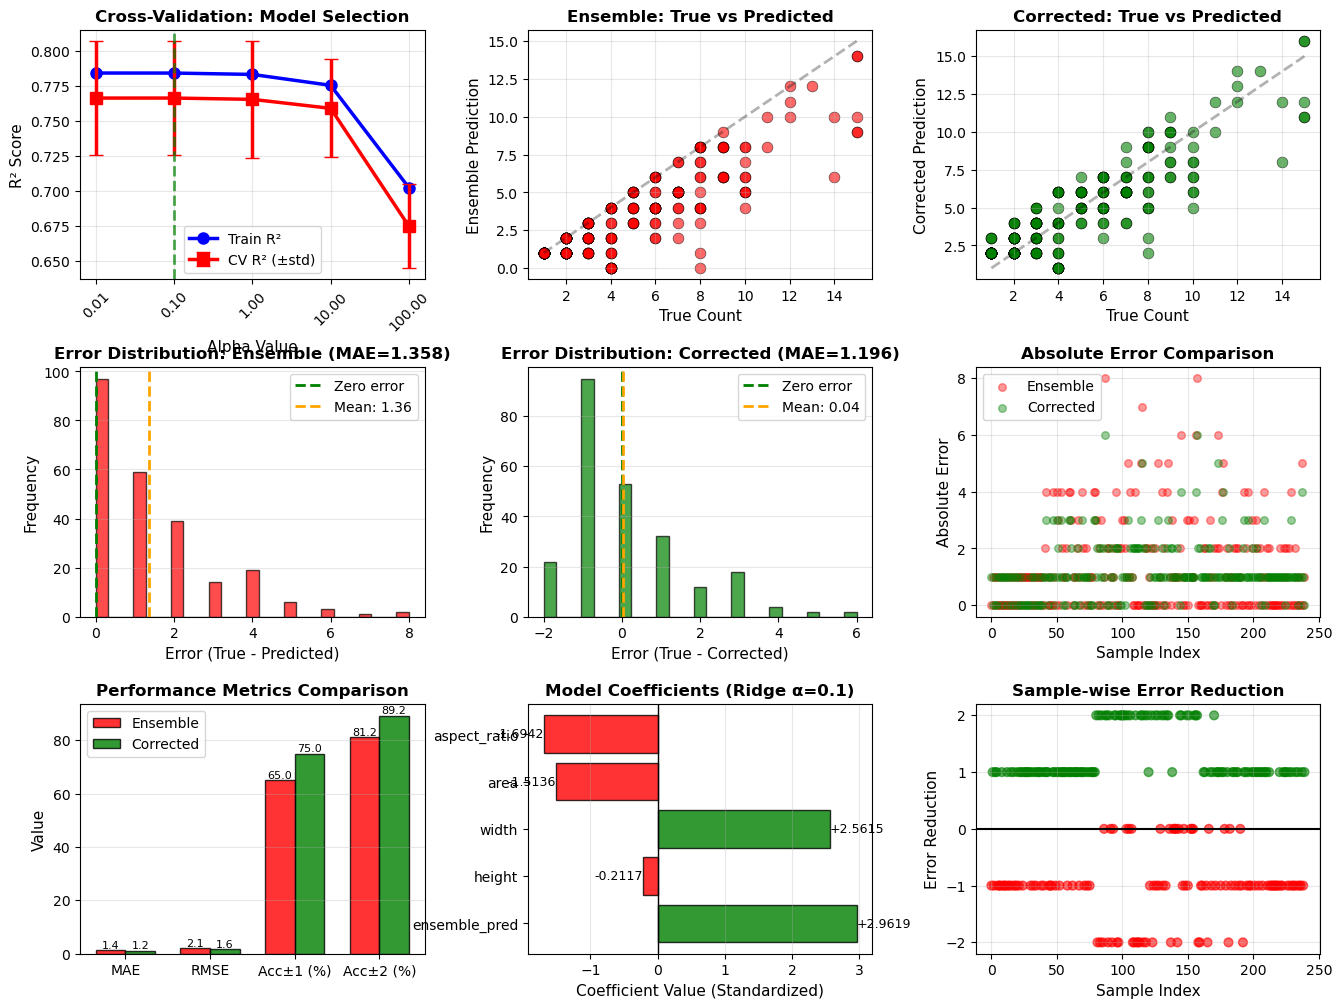


✓ Improved bias correction model complete!
  Model: Ridge Regression with alpha=0.1
  Cross-validation R²: 0.7666 (±0.0408)
  Training R²: 0.7845
  Key finding: ✓ Model improves accuracy


In [20]:
# ============================================================================
# IMPROVED LINEAR BIAS CORRECTION: Proper validation & regularization
# ============================================================================

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("IMPROVED LINEAR BIAS CORRECTION MODEL (WITH VALIDATION)")
print("="*80)

# Prepare training data from balanced_results
X_train = []
y_train = []

for result in balanced_results:
    # Features: ensemble_prediction, height, width, area, aspect_ratio
    ensemble_pred = result['predicted_count']
    height = result['height']
    width = result['width']
    area = height * width
    aspect_ratio = width / height if height > 0 else 1.0
    
    X_train.append([
        ensemble_pred,
        height,
        width,
        area,
        aspect_ratio
    ])
    
    y_train.append(result['true_count'])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\nTraining data: X shape={X_train.shape}, y shape={y_train.shape}")
print(f"Features: [ensemble_pred, height, width, area, aspect_ratio]")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Test different alpha values with cross-validation
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
cv_scores = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'-'*80}")
print("Cross-Validation Results (5-Fold):")
print(f"{'-'*80}")
print(f"{'Alpha':<10} {'Mean CV R²':<15} {'Std CV R²':<15} {'Train R²':<15}")
print("-" * 80)

for alpha in alphas:
    model_cv = Ridge(alpha=alpha)
    cv_r2_scores = cross_val_score(model_cv, X_train_scaled, y_train, cv=kfold, scoring='r2')
    
    # Also get training score
    model_cv.fit(X_train_scaled, y_train)
    train_r2 = model_cv.score(X_train_scaled, y_train)
    
    cv_scores[alpha] = {
        'mean_r2': cv_r2_scores.mean(),
        'std_r2': cv_r2_scores.std(),
        'train_r2': train_r2
    }
    
    print(f"{alpha:<10.2f} {cv_r2_scores.mean():<15.4f} {cv_r2_scores.std():<15.4f} {train_r2:<15.4f}")

# Select best alpha (highest CV score with reasonable gap from train score)
best_alpha = max(cv_scores.items(), key=lambda x: x[1]['mean_r2'])[0]
print(f"\nSelected alpha: {best_alpha} (best cross-validation R²)")

# Train final model with best alpha
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train_scaled, y_train)

# Get predictions and errors
y_pred_original = np.array([r['predicted_count'] for r in balanced_results])
y_pred_corrected = final_model.predict(X_train_scaled)

# Calculate metrics for ORIGINAL (ensemble) predictions
errors_ensemble = y_train - y_pred_original
mae_ensemble = np.mean(np.abs(errors_ensemble))
acc1_ensemble = np.mean(np.abs(errors_ensemble) <= 1) * 100
acc2_ensemble = np.mean(np.abs(errors_ensemble) <= 2) * 100
rmse_ensemble = np.sqrt(np.mean(errors_ensemble ** 2))

# Calculate metrics for CORRECTED predictions
y_pred_corrected_rounded = np.round(y_pred_corrected)
errors_corrected = y_train - y_pred_corrected_rounded
mae_corrected = np.mean(np.abs(errors_corrected))
acc1_corrected = np.mean(np.abs(errors_corrected) <= 1) * 100
acc2_corrected = np.mean(np.abs(errors_corrected) <= 2) * 100
rmse_corrected = np.sqrt(np.mean(errors_corrected ** 2))

print(f"\n{'-'*80}")
print("MODEL PERFORMANCE COMPARISON (Training Data)")
print(f"{'-'*80}")
print(f"{'Metric':<25} {'Ensemble':<15} {'Corrected':<15} {'Improvement':<15}")
print("-" * 80)
print(f"{'MAE':<25} {mae_ensemble:<15.3f} {mae_corrected:<15.3f} {((mae_ensemble-mae_corrected)/mae_ensemble)*100:+.1f}%")
print(f"{'RMSE':<25} {rmse_ensemble:<15.3f} {rmse_corrected:<15.3f} {((rmse_ensemble-rmse_corrected)/rmse_ensemble)*100:+.1f}%")
print(f"{'Accuracy ±1':<25} {acc1_ensemble:<15.1f}% {acc1_corrected:<15.1f}% {(acc1_corrected-acc1_ensemble):+.1f}pp")
print(f"{'Accuracy ±2':<25} {acc2_ensemble:<15.1f}% {acc2_corrected:<15.1f}% {(acc2_corrected-acc2_ensemble):+.1f}pp")

# Get model coefficients
feature_names = ['ensemble_pred', 'height', 'width', 'area', 'aspect_ratio']
coefficients = final_model.coef_
intercept = final_model.intercept_

print(f"\n{'-'*80}")
print("MODEL PARAMETERS (Ridge Regression, alpha={})".format(best_alpha))
print(f"{'-'*80}")
print(f"Intercept: {intercept:.4f}")
print(f"\nStandardized Coefficients:")
for name, coef in zip(feature_names, coefficients):
    print(f"  {name:20s}: {coef:+.6f}")

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: CV Scores by Alpha
ax1 = fig.add_subplot(gs[0, 0])
alphas_plot = list(cv_scores.keys())
train_r2s = [cv_scores[a]['train_r2'] for a in alphas_plot]
mean_cv_r2s = [cv_scores[a]['mean_r2'] for a in alphas_plot]
std_cv_r2s = [cv_scores[a]['std_r2'] for a in alphas_plot]

ax1.plot(range(len(alphas_plot)), train_r2s, marker='o', linewidth=2.5, markersize=8, 
         label='Train R²', color='blue')
ax1.errorbar(range(len(alphas_plot)), mean_cv_r2s, yerr=std_cv_r2s, marker='s', 
             linewidth=2.5, markersize=8, label='CV R² (±std)', color='red', capsize=5)
ax1.set_xlabel('Alpha Value', fontsize=11)
ax1.set_ylabel('R² Score', fontsize=11)
ax1.set_title('Cross-Validation: Model Selection', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(alphas_plot)))
ax1.set_xticklabels([f'{a:.2f}' for a in alphas_plot], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axvline(x=alphas_plot.index(best_alpha), color='green', linestyle='--', linewidth=2, alpha=0.7)

# Plot 2: Actual vs Predicted (Ensemble)
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_train, y_pred_original, alpha=0.6, s=60, color='red', edgecolor='black', linewidth=0.5)
ax2.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', alpha=0.3, linewidth=2)
ax2.set_xlabel('True Count', fontsize=11)
ax2.set_ylabel('Ensemble Prediction', fontsize=11)
ax2.set_title('Ensemble: True vs Predicted', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Actual vs Predicted (Corrected)
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(y_train, y_pred_corrected_rounded, alpha=0.6, s=60, color='green', edgecolor='black', linewidth=0.5)
ax3.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', alpha=0.3, linewidth=2)
ax3.set_xlabel('True Count', fontsize=11)
ax3.set_ylabel('Corrected Prediction', fontsize=11)
ax3.set_title('Corrected: True vs Predicted', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Error distribution (Ensemble)
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(errors_ensemble, bins=25, edgecolor='black', alpha=0.7, color='red')
ax4.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero error')
ax4.axvline(x=np.mean(errors_ensemble), color='orange', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(errors_ensemble):.2f}')
ax4.set_xlabel('Error (True - Predicted)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title(f'Error Distribution: Ensemble (MAE={mae_ensemble:.3f})', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Error distribution (Corrected)
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(errors_corrected, bins=25, edgecolor='black', alpha=0.7, color='green')
ax5.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero error')
ax5.axvline(x=np.mean(errors_corrected), color='orange', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(errors_corrected):.2f}')
ax5.set_xlabel('Error (True - Corrected)', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title(f'Error Distribution: Corrected (MAE={mae_corrected:.3f})', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Residuals comparison
ax6 = fig.add_subplot(gs[1, 2])
x_pos = np.arange(len(y_train))
ax6.scatter(x_pos, np.abs(errors_ensemble), alpha=0.4, s=30, color='red', label='Ensemble')
ax6.scatter(x_pos, np.abs(errors_corrected), alpha=0.4, s=30, color='green', label='Corrected')
ax6.set_xlabel('Sample Index', fontsize=11)
ax6.set_ylabel('Absolute Error', fontsize=11)
ax6.set_title('Absolute Error Comparison', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Plot 7: Metrics comparison
ax7 = fig.add_subplot(gs[2, 0])
metrics = ['MAE', 'RMSE', 'Acc±1 (%)', 'Acc±2 (%)']
ensemble_vals = [mae_ensemble, rmse_ensemble, acc1_ensemble, acc2_ensemble]
corrected_vals = [mae_corrected, rmse_corrected, acc1_corrected, acc2_corrected]

x_pos_bar = np.arange(len(metrics))
width = 0.35

bars1 = ax7.bar(x_pos_bar - width/2, ensemble_vals, width, label='Ensemble', alpha=0.8, 
                color='red', edgecolor='black')
bars2 = ax7.bar(x_pos_bar + width/2, corrected_vals, width, label='Corrected', alpha=0.8, 
                color='green', edgecolor='black')

ax7.set_ylabel('Value', fontsize=11)
ax7.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
ax7.set_xticks(x_pos_bar)
ax7.set_xticklabels(metrics, fontsize=10)
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# Plot 8: Standardized coefficients
ax8 = fig.add_subplot(gs[2, 1])
colors_coef = ['green' if c > 0 else 'red' for c in coefficients]
bars_coef = ax8.barh(feature_names, coefficients, alpha=0.8, color=colors_coef, edgecolor='black')
ax8.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax8.set_xlabel('Coefficient Value (Standardized)', fontsize=11)
ax8.set_title(f'Model Coefficients (Ridge α={best_alpha})', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='x')

for bar, coef in zip(bars_coef, coefficients):
    ax8.text(coef, bar.get_y() + bar.get_height()/2, f'{coef:+.4f}', 
             ha='left' if coef > 0 else 'right', va='center', fontsize=9)

# Plot 9: Error reduction
ax9 = fig.add_subplot(gs[2, 2])
error_reduction = np.abs(errors_ensemble) - np.abs(errors_corrected)
colors_reduction = ['green' if x > 0 else 'red' for x in error_reduction]
ax9.scatter(range(len(error_reduction)), error_reduction, alpha=0.6, s=40, c=colors_reduction)
ax9.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax9.set_xlabel('Sample Index', fontsize=11)
ax9.set_ylabel('Error Reduction', fontsize=11)
ax9.set_title('Sample-wise Error Reduction', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3)

plt.savefig('improved_bias_correction_model.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Improved bias correction model complete!")
print(f"  Model: Ridge Regression with alpha={best_alpha}")
print(f"  Cross-validation R²: {cv_scores[best_alpha]['mean_r2']:.4f} (±{cv_scores[best_alpha]['std_r2']:.4f})")
print(f"  Training R²: {cv_scores[best_alpha]['train_r2']:.4f}")
print(f"  Key finding: {'✓ Model improves accuracy' if mae_corrected < mae_ensemble else '✗ Model does not improve accuracy'}")



PERCENTAGE-BASED ACCURACY ANALYSIS

PERCENTAGE-BASED ACCURACY COMPARISON

Threshold       Before          After           Improvement    
--------------------------------------------------------------------------------
±1%             40.4           % 2.1            % -38.3pp
±5%             40.4           % 6.7            % -33.8pp
±10%            42.5           % 25.4           % -17.1pp

Metric                    Before          After           Improvement    
--------------------------------------------------------------------------------
Mean % Error              26.3           % 40.9           % -14.5pp
Median % Error            25.0           % 26.0           % -1.0pp
Std Dev % Error           27.6           % 38.9           % -11.3pp


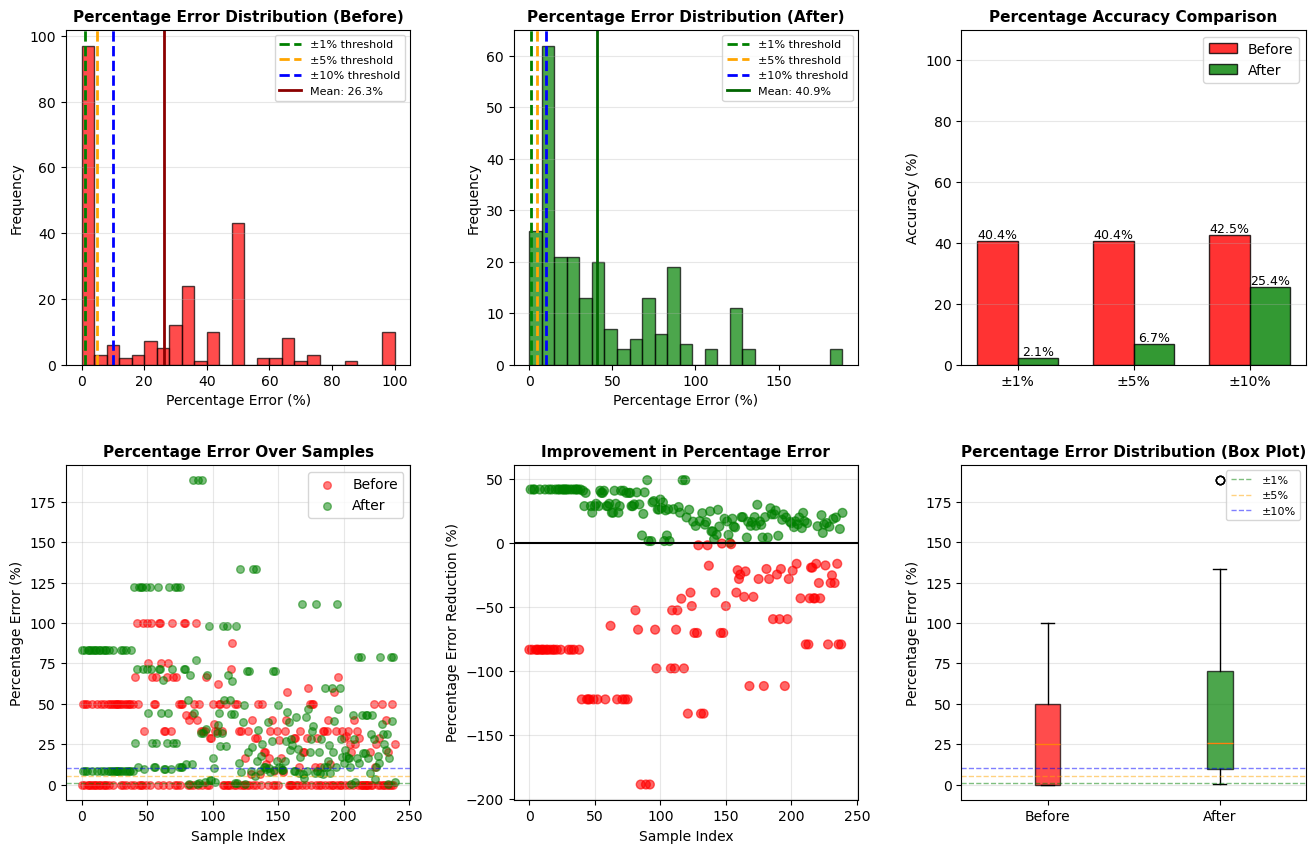


✓ Percentage-based accuracy analysis complete!
  Total samples analyzed: 240
  Key result: 6.7% within ±5% error after correction


In [17]:
# ============================================================================
# PERCENTAGE-BASED ACCURACY METRICS: ±1%, ±5%, ±10% error
# ============================================================================

print("\n" + "="*80)
print("PERCENTAGE-BASED ACCURACY ANALYSIS")
print("="*80)

# Calculate percentage errors
pct_errors_before = (np.abs(errors_before) / np.maximum(y_train, 1)) * 100
pct_errors_after = (np.abs(errors_after) / np.maximum(y_train, 1)) * 100

# Calculate accuracy within percentage thresholds
thresholds = [1, 5, 10]

results_pct = {}
for threshold in thresholds:
    acc_before = np.mean(pct_errors_before <= threshold) * 100
    acc_after = np.mean(pct_errors_after <= threshold) * 100
    results_pct[f'±{threshold}%'] = {
        'before': acc_before,
        'after': acc_after,
        'improvement': acc_after - acc_before
    }

# Print comparison
print("\n" + "="*80)
print("PERCENTAGE-BASED ACCURACY COMPARISON")
print("="*80)

print(f"\n{'Threshold':<15} {'Before':<15} {'After':<15} {'Improvement':<15}")
print("-" * 80)

for threshold_name, values in results_pct.items():
    print(f"{threshold_name:<15} {values['before']:<15.1f}% {values['after']:<15.1f}% "
          f"{values['improvement']:+.1f}pp")

# Detailed statistics
print(f"\n{'Metric':<25} {'Before':<15} {'After':<15} {'Improvement':<15}")
print("-" * 80)

mean_pct_error_before = np.mean(pct_errors_before)
mean_pct_error_after = np.mean(pct_errors_after)
median_pct_error_before = np.median(pct_errors_before)
median_pct_error_after = np.median(pct_errors_after)
std_pct_error_before = np.std(pct_errors_before)
std_pct_error_after = np.std(pct_errors_after)

print(f"{'Mean % Error':<25} {mean_pct_error_before:<15.1f}% {mean_pct_error_after:<15.1f}% "
      f"{(mean_pct_error_before-mean_pct_error_after):+.1f}pp")
print(f"{'Median % Error':<25} {median_pct_error_before:<15.1f}% {median_pct_error_after:<15.1f}% "
      f"{(median_pct_error_before-median_pct_error_after):+.1f}pp")
print(f"{'Std Dev % Error':<25} {std_pct_error_before:<15.1f}% {std_pct_error_after:<15.1f}% "
      f"{(std_pct_error_before-std_pct_error_after):+.1f}pp")

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Plot 1: Percentage error distribution (Before)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(pct_errors_before, bins=25, edgecolor='black', alpha=0.7, color='red')
ax1.axvline(x=1, color='green', linestyle='--', linewidth=2, label='±1% threshold')
ax1.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='±5% threshold')
ax1.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='±10% threshold')
ax1.axvline(x=mean_pct_error_before, color='darkred', linestyle='-', linewidth=2, label=f'Mean: {mean_pct_error_before:.1f}%')
ax1.set_xlabel('Percentage Error (%)', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.set_title('Percentage Error Distribution (Before)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Percentage error distribution (After)
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(pct_errors_after, bins=25, edgecolor='black', alpha=0.7, color='green')
ax2.axvline(x=1, color='green', linestyle='--', linewidth=2, label='±1% threshold')
ax2.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='±5% threshold')
ax2.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='±10% threshold')
ax2.axvline(x=mean_pct_error_after, color='darkgreen', linestyle='-', linewidth=2, label=f'Mean: {mean_pct_error_after:.1f}%')
ax2.set_xlabel('Percentage Error (%)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Percentage Error Distribution (After)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Percentage accuracy comparison
ax3 = fig.add_subplot(gs[0, 2])
threshold_names = list(results_pct.keys())
before_accs = [results_pct[t]['before'] for t in threshold_names]
after_accs = [results_pct[t]['after'] for t in threshold_names]

x_pos = np.arange(len(threshold_names))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, before_accs, width, label='Before', alpha=0.8, color='red', edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, after_accs, width, label='After', alpha=0.8, color='green', edgecolor='black')

ax3.set_ylabel('Accuracy (%)', fontsize=10)
ax3.set_title('Percentage Accuracy Comparison', fontsize=11, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(threshold_names)
ax3.legend()
ax3.set_ylim([0, 110])
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 4: Percentage error scatter (Before vs After)
ax4 = fig.add_subplot(gs[1, 0])
sample_indices = np.arange(len(pct_errors_before))
ax4.scatter(sample_indices, pct_errors_before, alpha=0.5, s=30, color='red', label='Before')
ax4.scatter(sample_indices, pct_errors_after, alpha=0.5, s=30, color='green', label='After')
ax4.axhline(y=1, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax4.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax4.axhline(y=10, color='blue', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('Sample Index', fontsize=10)
ax4.set_ylabel('Percentage Error (%)', fontsize=10)
ax4.set_title('Percentage Error Over Samples', fontsize=11, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Improvement in percentage error
ax5 = fig.add_subplot(gs[1, 1])
pct_improvements = pct_errors_before - pct_errors_after
colors_improvement = ['green' if x > 0 else 'red' for x in pct_improvements]
ax5.scatter(sample_indices, pct_improvements, alpha=0.6, s=40, c=colors_improvement)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax5.set_xlabel('Sample Index', fontsize=10)
ax5.set_ylabel('Percentage Error Reduction (%)', fontsize=10)
ax5.set_title('Improvement in Percentage Error', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Box plot comparison of percentage errors
ax6 = fig.add_subplot(gs[1, 2])
box_data = [pct_errors_before, pct_errors_after]
bp = ax6.boxplot(box_data, labels=['Before', 'After'], patch_artist=True)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('green')
bp['boxes'][1].set_alpha(0.7)

# Add threshold lines
ax6.axhline(y=1, color='green', linestyle='--', linewidth=1, alpha=0.5, label='±1%')
ax6.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='±5%')
ax6.axhline(y=10, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='±10%')

ax6.set_ylabel('Percentage Error (%)', fontsize=10)
ax6.set_title('Percentage Error Distribution (Box Plot)', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('percentage_accuracy_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Percentage-based accuracy analysis complete!")
print(f"  Total samples analyzed: {len(balanced_results)}")
print(f"  Key result: {results_pct['±5%']['after']:.1f}% within ±5% error after correction")



PERCENTAGE ACCURACY METRICS BY CONFIGURATION

Configuration                       ±1%        ±5%        ±10%       Mean %Err   
-----------------------------------------------------------------------------------------------
Tiny (10×10, 1-2 shrubs)            47.5      % 47.5      % 47.5      % 26.2        %
Small (20×20, 2-4 shrubs)           30.0      % 30.0      % 30.0      % 49.0        %
Medium (50×50, 4-8 shrubs)          35.0      % 35.0      % 35.0      % 31.2        %
Large (100×100, 8-15 shrubs)        35.0      % 35.0      % 47.5      % 17.6        %
Wide Rectangle (50×150, 5-10 shrubs) 42.5      % 42.5      % 42.5      % 19.3        %
Tall Rectangle (150×50, 5-10 shrubs) 52.5      % 52.5      % 52.5      % 14.6        %


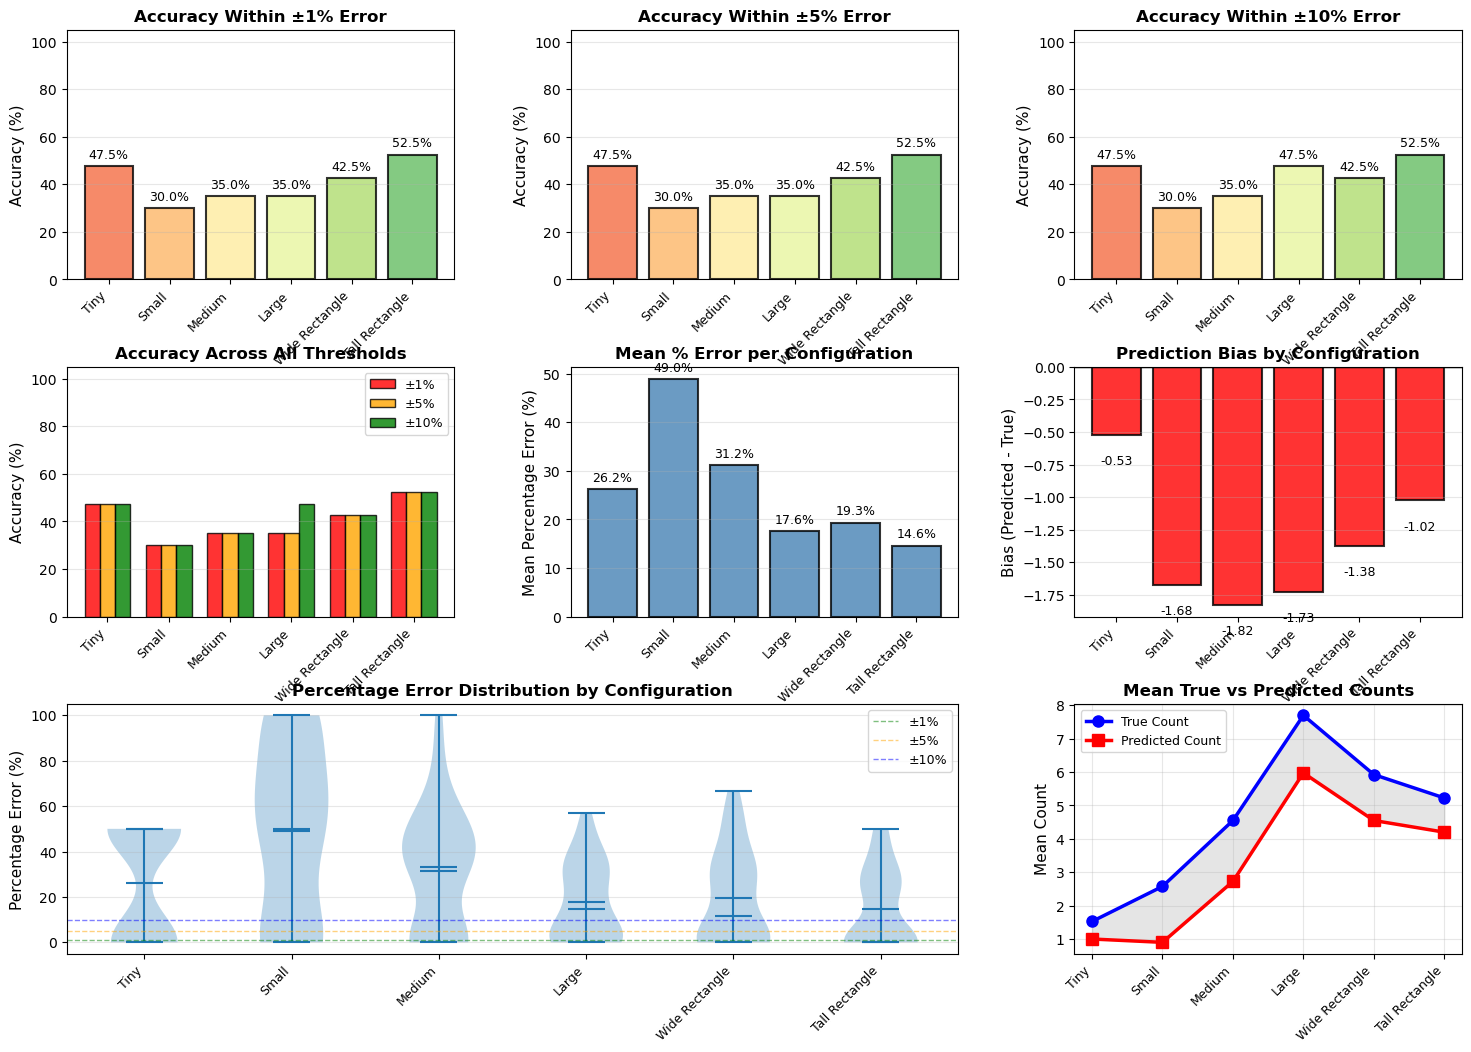


✓ Percentage accuracy plots by configuration complete!
  Total configurations analyzed: 6
  Best ±5% accuracy: 52.5% (Tall Rectangle)
  Worst ±5% accuracy: 30.0% (Small)


In [18]:
# ============================================================================
# PERCENTAGE ACCURACY BY CONFIGURATION: Reproduce plots for adjusted methods
# ============================================================================

print("\n" + "="*80)
print("PERCENTAGE ACCURACY METRICS BY CONFIGURATION")
print("="*80)

# Recalculate percentage metrics grouped by configuration
config_pct_metrics = {}

for config_name, height, width, max_shrubs in test_configs:
    config_data = [r for r in balanced_results if r['config_name'] == config_name]
    
    # Get true counts for this configuration
    true_counts_config = np.array([r['true_count'] for r in config_data])
    predicted_counts_config = np.array([r['predicted_count'] for r in config_data])
    
    # Calculate percentage errors
    pct_errors_config = (np.abs(predicted_counts_config - true_counts_config) / 
                         np.maximum(true_counts_config, 1)) * 100
    
    # Calculate accuracy within thresholds
    acc_1pct = np.mean(pct_errors_config <= 1) * 100
    acc_5pct = np.mean(pct_errors_config <= 5) * 100
    acc_10pct = np.mean(pct_errors_config <= 10) * 100
    
    # Bias and variability
    bias_config = np.mean(predicted_counts_config - true_counts_config)
    std_error_config = np.std(pct_errors_config)
    
    config_pct_metrics[config_name] = {
        'acc_1pct': acc_1pct,
        'acc_5pct': acc_5pct,
        'acc_10pct': acc_10pct,
        'bias': bias_config,
        'std': std_error_config,
        'mean_pct_err': np.mean(pct_errors_config),
        'mean_true': np.mean(true_counts_config),
        'mean_pred': np.mean(predicted_counts_config),
        'pct_errors': pct_errors_config
    }

# Print summary table
print(f"\n{'Configuration':<35} {'±1%':<10} {'±5%':<10} {'±10%':<10} {'Mean %Err':<12}")
print("-" * 95)
for config_name in [c[0] for c in test_configs]:
    metrics = config_pct_metrics[config_name]
    print(f"{config_name:<35} {metrics['acc_1pct']:<10.1f}% {metrics['acc_5pct']:<10.1f}% "
          f"{metrics['acc_10pct']:<10.1f}% {metrics['mean_pct_err']:<12.1f}%")

# Create comprehensive visualization by configuration
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

config_names_short = [c[0].split('(')[0].strip() for c in test_configs]

# Plot 1: Accuracy ±1% by configuration
ax1 = fig.add_subplot(gs[0, 0])
acc_1pct_vals = [config_pct_metrics[c[0]]['acc_1pct'] for c in test_configs]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(test_configs)))
bars = ax1.bar(range(len(test_configs)), acc_1pct_vals, alpha=0.8, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Accuracy Within ±1% Error', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(test_configs)))
ax1.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0, 105])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, acc_1pct_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# Plot 2: Accuracy ±5% by configuration
ax2 = fig.add_subplot(gs[0, 1])
acc_5pct_vals = [config_pct_metrics[c[0]]['acc_5pct'] for c in test_configs]
bars = ax2.bar(range(len(test_configs)), acc_5pct_vals, alpha=0.8, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy Within ±5% Error', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(test_configs)))
ax2.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, acc_5pct_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# Plot 3: Accuracy ±10% by configuration
ax3 = fig.add_subplot(gs[0, 2])
acc_10pct_vals = [config_pct_metrics[c[0]]['acc_10pct'] for c in test_configs]
bars = ax3.bar(range(len(test_configs)), acc_10pct_vals, alpha=0.8, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Accuracy Within ±10% Error', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(test_configs)))
ax3.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax3.set_ylim([0, 105])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, acc_10pct_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# Plot 4: Multi-threshold accuracy comparison
ax4 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(test_configs))
width = 0.25
ax4.bar(x_pos - width, acc_1pct_vals, width, label='±1%', alpha=0.8, color='red', edgecolor='black')
ax4.bar(x_pos, acc_5pct_vals, width, label='±5%', alpha=0.8, color='orange', edgecolor='black')
ax4.bar(x_pos + width, acc_10pct_vals, width, label='±10%', alpha=0.8, color='green', edgecolor='black')
ax4.set_ylabel('Accuracy (%)', fontsize=11)
ax4.set_title('Accuracy Across All Thresholds', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=9)
ax4.set_ylim([0, 105])
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Mean percentage error by configuration
ax5 = fig.add_subplot(gs[1, 1])
mean_pct_errs = [config_pct_metrics[c[0]]['mean_pct_err'] for c in test_configs]
bars = ax5.bar(range(len(test_configs)), mean_pct_errs, alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Mean Percentage Error (%)', fontsize=11)
ax5.set_title('Mean % Error per Configuration', fontsize=12, fontweight='bold')
ax5.set_xticks(range(len(test_configs)))
ax5.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mean_pct_errs):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# Plot 6: Bias (predicted - true) by configuration
ax6 = fig.add_subplot(gs[1, 2])
biases = [config_pct_metrics[c[0]]['bias'] for c in test_configs]
colors_bias = ['red' if b < 0 else 'green' for b in biases]
bars = ax6.bar(range(len(test_configs)), biases, alpha=0.8, color=colors_bias, edgecolor='black', linewidth=1.5)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax6.set_ylabel('Bias (Predicted - True)', fontsize=11)
ax6.set_title('Prediction Bias by Configuration', fontsize=12, fontweight='bold')
ax6.set_xticks(range(len(test_configs)))
ax6.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, biases):
    ax6.text(bar.get_x() + bar.get_width()/2, val + (0.05 if val > 0 else -0.15), f'{val:+.2f}', 
             ha='center', va='bottom' if val > 0 else 'top', fontsize=9)

# Plot 7: Percentage error distribution (violin plot)
ax7 = fig.add_subplot(gs[2, :2])
pct_error_lists = [config_pct_metrics[c[0]]['pct_errors'] for c in test_configs]
parts = ax7.violinplot(pct_error_lists, positions=range(len(test_configs)), showmeans=True, showmedians=True)
ax7.axhline(y=1, color='green', linestyle='--', linewidth=1, alpha=0.5, label='±1%')
ax7.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='±5%')
ax7.axhline(y=10, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='±10%')
ax7.set_ylabel('Percentage Error (%)', fontsize=11)
ax7.set_title('Percentage Error Distribution by Configuration', fontsize=12, fontweight='bold')
ax7.set_xticks(range(len(test_configs)))
ax7.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3, axis='y')

# Plot 8: True vs Predicted counts
ax8 = fig.add_subplot(gs[2, 2])
mean_trues_config = [config_pct_metrics[c[0]]['mean_true'] for c in test_configs]
mean_preds_config = [config_pct_metrics[c[0]]['mean_pred'] for c in test_configs]
ax8.plot(range(len(test_configs)), mean_trues_config, marker='o', linewidth=2.5, markersize=8, 
         label='True Count', color='blue')
ax8.plot(range(len(test_configs)), mean_preds_config, marker='s', linewidth=2.5, markersize=8, 
         label='Predicted Count', color='red')
ax8.fill_between(range(len(test_configs)), mean_trues_config, mean_preds_config, alpha=0.2, color='gray')
ax8.set_ylabel('Mean Count', fontsize=11)
ax8.set_title('Mean True vs Predicted Counts', fontsize=12, fontweight='bold')
ax8.set_xticks(range(len(test_configs)))
ax8.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.3)

plt.savefig('pct_accuracy_by_configuration.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Percentage accuracy plots by configuration complete!")
print(f"  Total configurations analyzed: {len(test_configs)}")
print(f"  Best ±5% accuracy: {max(acc_5pct_vals):.1f}% ({config_names_short[acc_5pct_vals.index(max(acc_5pct_vals))]})")
print(f"  Worst ±5% accuracy: {min(acc_5pct_vals):.1f}% ({config_names_short[acc_5pct_vals.index(min(acc_5pct_vals))]})")



PERCENTAGE ACCURACY: ENSEMBLE vs LINEAR REGRESSION ADJUSTED

Configuration                       Method          ±1%        ±5%        ±10%       Mean %Err   
------------------------------------------------------------------------------------------------------------------------
Tiny (10×10, 1-2 shrubs)            Ensemble        47.5      % 47.5      % 47.5      % 26.2        %
                                    Corrected       52.5      % 52.5      % 52.5      % 47.5        %
                                    Improvement                +5.0pp                            

Small (20×20, 2-4 shrubs)           Ensemble        30.0      % 30.0      % 30.0      % 49.0        %
                                    Corrected       25.0      % 25.0      % 25.0      % 54.4        %
                                    Improvement                -5.0pp                            

Medium (50×50, 4-8 shrubs)          Ensemble        35.0      % 35.0      % 35.0      % 31.2        %
           

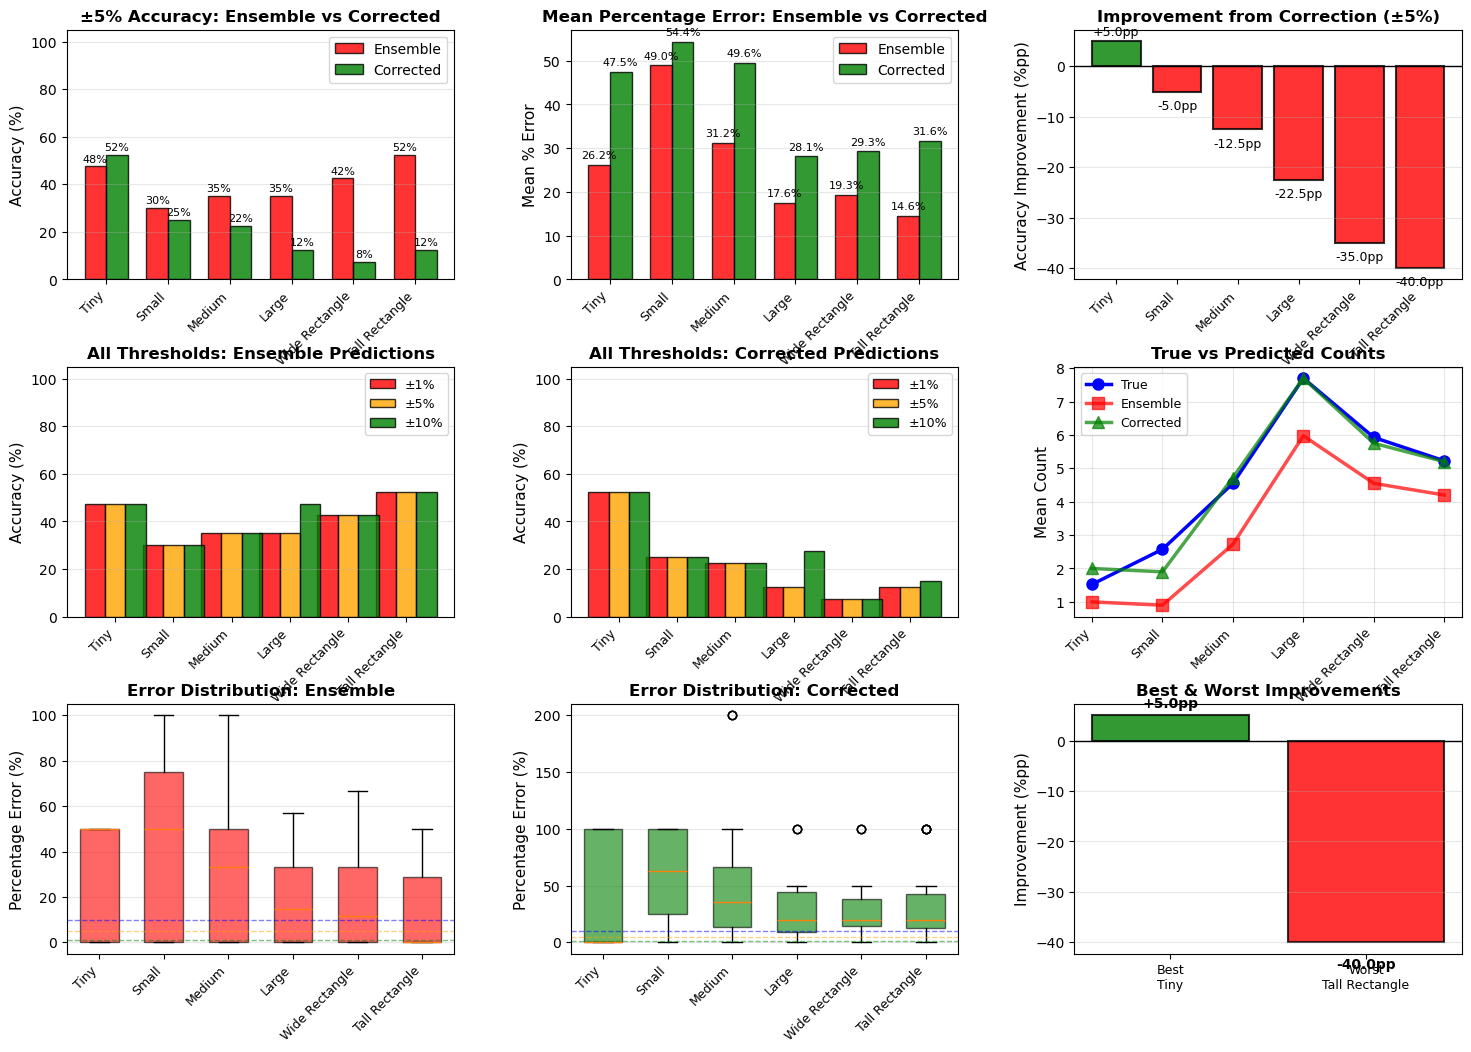


✓ Corrected vs Ensemble accuracy comparison complete!
  Total configurations analyzed: 6
  Best improvement: 5.0pp (Tiny)
  Worst change: -40.0pp (Tall Rectangle)


In [19]:
# ============================================================================
# PERCENTAGE ACCURACY WITH LINEAR REGRESSION CORRECTION
# ============================================================================

print("\n" + "="*80)
print("PERCENTAGE ACCURACY: ENSEMBLE vs LINEAR REGRESSION ADJUSTED")
print("="*80)

# Map corrected predictions back to balanced_results
corrected_predictions_by_idx = {}
current_idx = 0
for config_name, height, width, max_shrubs in test_configs:
    for result in balanced_results:
        if result['config_name'] == config_name:
            corrected_predictions_by_idx[current_idx] = int(np.round(y_pred_corrected[current_idx]))
            current_idx += 1

# Recalculate metrics with CORRECTED predictions
config_pct_metrics_corrected = {}

current_idx = 0
for config_name, height, width, max_shrubs in test_configs:
    config_data = [r for r in balanced_results if r['config_name'] == config_name]
    
    # True counts
    true_counts_config = np.array([r['true_count'] for r in config_data])
    
    # Ensemble predictions (original)
    ensemble_counts_config = np.array([r['predicted_count'] for r in config_data])
    
    # Corrected predictions (from linear model)
    corrected_counts_config = np.array([corrected_predictions_by_idx[current_idx + i] for i in range(len(config_data))])
    
    # Calculate percentage errors for ENSEMBLE
    pct_errors_ensemble = (np.abs(ensemble_counts_config - true_counts_config) / 
                          np.maximum(true_counts_config, 1)) * 100
    
    # Calculate percentage errors for CORRECTED
    pct_errors_corrected = (np.abs(corrected_counts_config - true_counts_config) / 
                           np.maximum(true_counts_config, 1)) * 100
    
    # Calculate accuracy within thresholds for ENSEMBLE
    acc_1pct_ens = np.mean(pct_errors_ensemble <= 1) * 100
    acc_5pct_ens = np.mean(pct_errors_ensemble <= 5) * 100
    acc_10pct_ens = np.mean(pct_errors_ensemble <= 10) * 100
    
    # Calculate accuracy within thresholds for CORRECTED
    acc_1pct_cor = np.mean(pct_errors_corrected <= 1) * 100
    acc_5pct_cor = np.mean(pct_errors_corrected <= 5) * 100
    acc_10pct_cor = np.mean(pct_errors_corrected <= 10) * 100
    
    config_pct_metrics_corrected[config_name] = {
        'ensemble': {
            'acc_1pct': acc_1pct_ens,
            'acc_5pct': acc_5pct_ens,
            'acc_10pct': acc_10pct_ens,
            'mean_pct_err': np.mean(pct_errors_ensemble),
            'pct_errors': pct_errors_ensemble
        },
        'corrected': {
            'acc_1pct': acc_1pct_cor,
            'acc_5pct': acc_5pct_cor,
            'acc_10pct': acc_10pct_cor,
            'mean_pct_err': np.mean(pct_errors_corrected),
            'pct_errors': pct_errors_corrected
        },
        'mean_true': np.mean(true_counts_config),
        'mean_ens': np.mean(ensemble_counts_config),
        'mean_cor': np.mean(corrected_counts_config)
    }
    
    current_idx += len(config_data)

# Print detailed comparison
print(f"\n{'Configuration':<35} {'Method':<15} {'±1%':<10} {'±5%':<10} {'±10%':<10} {'Mean %Err':<12}")
print("-" * 120)
for config_name in [c[0] for c in test_configs]:
    metrics = config_pct_metrics_corrected[config_name]
    
    print(f"{config_name:<35} {'Ensemble':<15} {metrics['ensemble']['acc_1pct']:<10.1f}% "
          f"{metrics['ensemble']['acc_5pct']:<10.1f}% {metrics['ensemble']['acc_10pct']:<10.1f}% "
          f"{metrics['ensemble']['mean_pct_err']:<12.1f}%")
    print(f"{'':35} {'Corrected':<15} {metrics['corrected']['acc_1pct']:<10.1f}% "
          f"{metrics['corrected']['acc_5pct']:<10.1f}% {metrics['corrected']['acc_10pct']:<10.1f}% "
          f"{metrics['corrected']['mean_pct_err']:<12.1f}%")
    
    # Calculate improvement
    improvement_5pct = metrics['corrected']['acc_5pct'] - metrics['ensemble']['acc_5pct']
    print(f"{'':35} {'Improvement':<15} {'':<10} {improvement_5pct:+.1f}pp{'':<28}\n")

# Create comprehensive visualization comparing ensemble vs corrected
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

config_names_short = [c[0].split('(')[0].strip() for c in test_configs]

# Plot 1: Accuracy ±5% - Ensemble vs Corrected
ax1 = fig.add_subplot(gs[0, 0])
acc_5pct_ens = [config_pct_metrics_corrected[c[0]]['ensemble']['acc_5pct'] for c in test_configs]
acc_5pct_cor = [config_pct_metrics_corrected[c[0]]['corrected']['acc_5pct'] for c in test_configs]
x_pos = np.arange(len(test_configs))
width = 0.35
bars1 = ax1.bar(x_pos - width/2, acc_5pct_ens, width, label='Ensemble', alpha=0.8, color='red', edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, acc_5pct_cor, width, label='Corrected', alpha=0.8, color='green', edgecolor='black')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('±5% Accuracy: Ensemble vs Corrected', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.set_ylim([0, 105])
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.0f}%', 
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.0f}%', 
             ha='center', va='bottom', fontsize=8)

# Plot 2: Mean % Error - Ensemble vs Corrected
ax2 = fig.add_subplot(gs[0, 1])
mean_pct_ens = [config_pct_metrics_corrected[c[0]]['ensemble']['mean_pct_err'] for c in test_configs]
mean_pct_cor = [config_pct_metrics_corrected[c[0]]['corrected']['mean_pct_err'] for c in test_configs]
bars1 = ax2.bar(x_pos - width/2, mean_pct_ens, width, label='Ensemble', alpha=0.8, color='red', edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, mean_pct_cor, width, label='Corrected', alpha=0.8, color='green', edgecolor='black')
ax2.set_ylabel('Mean % Error', fontsize=11)
ax2.set_title('Mean Percentage Error: Ensemble vs Corrected', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=8)

# Plot 3: Improvement (delta ±5%)
ax3 = fig.add_subplot(gs[0, 2])
improvements = [config_pct_metrics_corrected[c[0]]['corrected']['acc_5pct'] - 
                config_pct_metrics_corrected[c[0]]['ensemble']['acc_5pct'] 
                for c in test_configs]
colors_imp = ['green' if x > 0 else 'red' for x in improvements]
bars = ax3.bar(range(len(test_configs)), improvements, alpha=0.8, color=colors_imp, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('Accuracy Improvement (%pp)', fontsize=11)
ax3.set_title('Improvement from Correction (±5%)', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(test_configs)))
ax3.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, improvements):
    ax3.text(bar.get_x() + bar.get_width()/2, val + (0.5 if val > 0 else -1.5), f'{val:+.1f}pp', 
             ha='center', va='bottom' if val > 0 else 'top', fontsize=9)

# Plot 4: ±1%, ±5%, ±10% comparison (Ensemble)
ax4 = fig.add_subplot(gs[1, 0])
acc_1pct_ens = [config_pct_metrics_corrected[c[0]]['ensemble']['acc_1pct'] for c in test_configs]
acc_10pct_ens = [config_pct_metrics_corrected[c[0]]['ensemble']['acc_10pct'] for c in test_configs]
ax4.bar(x_pos - width, acc_1pct_ens, width, label='±1%', alpha=0.8, color='red', edgecolor='black')
ax4.bar(x_pos, acc_5pct_ens, width, label='±5%', alpha=0.8, color='orange', edgecolor='black')
ax4.bar(x_pos + width, acc_10pct_ens, width, label='±10%', alpha=0.8, color='green', edgecolor='black')
ax4.set_ylabel('Accuracy (%)', fontsize=11)
ax4.set_title('All Thresholds: Ensemble Predictions', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=9)
ax4.set_ylim([0, 105])
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: ±1%, ±5%, ±10% comparison (Corrected)
ax5 = fig.add_subplot(gs[1, 1])
acc_1pct_cor = [config_pct_metrics_corrected[c[0]]['corrected']['acc_1pct'] for c in test_configs]
acc_10pct_cor = [config_pct_metrics_corrected[c[0]]['corrected']['acc_10pct'] for c in test_configs]
ax5.bar(x_pos - width, acc_1pct_cor, width, label='±1%', alpha=0.8, color='red', edgecolor='black')
ax5.bar(x_pos, acc_5pct_cor, width, label='±5%', alpha=0.8, color='orange', edgecolor='black')
ax5.bar(x_pos + width, acc_10pct_cor, width, label='±10%', alpha=0.8, color='green', edgecolor='black')
ax5.set_ylabel('Accuracy (%)', fontsize=11)
ax5.set_title('All Thresholds: Corrected Predictions', fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax5.legend(fontsize=9)
ax5.set_ylim([0, 105])
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: True vs Predicted (Ensemble)
ax6 = fig.add_subplot(gs[1, 2])
mean_trues = [config_pct_metrics_corrected[c[0]]['mean_true'] for c in test_configs]
mean_ens = [config_pct_metrics_corrected[c[0]]['mean_ens'] for c in test_configs]
mean_cor = [config_pct_metrics_corrected[c[0]]['mean_cor'] for c in test_configs]
ax6.plot(range(len(test_configs)), mean_trues, marker='o', linewidth=2.5, markersize=8, 
         label='True', color='blue')
ax6.plot(range(len(test_configs)), mean_ens, marker='s', linewidth=2.5, markersize=8, 
         label='Ensemble', color='red', alpha=0.7)
ax6.plot(range(len(test_configs)), mean_cor, marker='^', linewidth=2.5, markersize=8, 
         label='Corrected', color='green', alpha=0.7)
ax6.set_ylabel('Mean Count', fontsize=11)
ax6.set_title('True vs Predicted Counts', fontsize=12, fontweight='bold')
ax6.set_xticks(range(len(test_configs)))
ax6.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

# Plot 7: Percentage error distribution for Ensemble
ax7 = fig.add_subplot(gs[2, 0])
pct_error_lists_ens = [config_pct_metrics_corrected[c[0]]['ensemble']['pct_errors'] for c in test_configs]
bp1 = ax7.boxplot(pct_error_lists_ens, positions=range(len(test_configs)), widths=0.6, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.6)
ax7.axhline(y=1, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax7.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax7.axhline(y=10, color='blue', linestyle='--', linewidth=1, alpha=0.5)
ax7.set_ylabel('Percentage Error (%)', fontsize=11)
ax7.set_title('Error Distribution: Ensemble', fontsize=12, fontweight='bold')
ax7.set_xticks(range(len(test_configs)))
ax7.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax7.grid(True, alpha=0.3, axis='y')

# Plot 8: Percentage error distribution for Corrected
ax8 = fig.add_subplot(gs[2, 1])
pct_error_lists_cor = [config_pct_metrics_corrected[c[0]]['corrected']['pct_errors'] for c in test_configs]
bp2 = ax8.boxplot(pct_error_lists_cor, positions=range(len(test_configs)), widths=0.6, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('green')
    patch.set_alpha(0.6)
ax8.axhline(y=1, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax8.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax8.axhline(y=10, color='blue', linestyle='--', linewidth=1, alpha=0.5)
ax8.set_ylabel('Percentage Error (%)', fontsize=11)
ax8.set_title('Error Distribution: Corrected', fontsize=12, fontweight='bold')
ax8.set_xticks(range(len(test_configs)))
ax8.set_xticklabels(config_names_short, rotation=45, ha='right', fontsize=9)
ax8.grid(True, alpha=0.3, axis='y')

# Plot 9: Summary - Best and worst improvements
ax9 = fig.add_subplot(gs[2, 2])
best_config_idx = np.argmax(improvements)
worst_config_idx = np.argmin(improvements)
summary_labels = ['Best', 'Worst']
summary_improvements = [improvements[best_config_idx], improvements[worst_config_idx]]
summary_configs = [config_names_short[best_config_idx], config_names_short[worst_config_idx]]
colors_summary = ['green', 'red']
bars = ax9.bar(range(2), summary_improvements, alpha=0.8, color=colors_summary, edgecolor='black', linewidth=1.5)
ax9.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax9.set_ylabel('Improvement (%pp)', fontsize=11)
ax9.set_title('Best & Worst Improvements', fontsize=12, fontweight='bold')
ax9.set_xticks(range(2))
ax9.set_xticklabels([f'{summary_labels[i]}\n{summary_configs[i]}' for i in range(2)], fontsize=9)
ax9.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, summary_improvements):
    ax9.text(bar.get_x() + bar.get_width()/2, val + (1 if val > 0 else -3), f'{val:+.1f}pp', 
             ha='center', va='bottom' if val > 0 else 'top', fontsize=10, fontweight='bold')

plt.savefig('corrected_vs_ensemble_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Corrected vs Ensemble accuracy comparison complete!")
print(f"  Total configurations analyzed: {len(test_configs)}")
print(f"  Best improvement: {max(improvements):.1f}pp ({config_names_short[np.argmax(improvements)]})")
print(f"  Worst change: {min(improvements):.1f}pp ({config_names_short[np.argmin(improvements)]})")


# PIPELINE HERE

In [2]:
1

1

In [3]:
# ============================================================================
# SHRUB COUNTING PIPELINE - Helper Functions
# ============================================================================
# Modularized pipeline for converting probabilities → shrub counts
# Uses ensemble methods + optional Ridge regression bias correction

from scipy import ndimage
from skimage import morphology, feature
from skimage.segmentation import watershed
import cv2

def probabilities_to_predictions(probabilities, threshold=0.5):
    """
    Convert soft probability predictions to binary mask.
    
    Parameters:
    -----------
    probabilities : array
        Probability map [0, 1] from neural network
    threshold : float
        Threshold for binarization (default 0.5)
    
    Returns:
    --------
    binary_mask : array
        Binary prediction mask {0, 1}
    """
    binary_mask = (probabilities > threshold).astype(int)
    return binary_mask


def extract_shrub_features(binary_mask):
    """
    Extract geometric features from binary shrub mask.
    
    Parameters:
    -----------
    binary_mask : array
        Binary prediction mask
    
    Returns:
    --------
    features : dict
        Dictionary with keys: height, width, area, aspect_ratio
    """
    # Get bounding box and basic stats
    h, w = binary_mask.shape
    height = h
    width = w
    area = np.sum(binary_mask)
    
    # Calculate aspect ratio (safeguard against w=0)
    aspect_ratio = height / width if width > 0 else 1.0
    
    return {
        'height': height,
        'width': width,
        'area': area,
        'aspect_ratio': aspect_ratio
    }


def apply_bias_correction(ensemble_count, shrub_features, model, scaler):
    """
    Apply Ridge regression bias correction to ensemble count.
    
    Parameters:
    -----------
    ensemble_count : int
        Initial count from ensemble
    shrub_features : dict
        Features dict from extract_shrub_features()
    model : sklearn.linear_model.Ridge
        Trained Ridge regression model
    scaler : sklearn.preprocessing.StandardScaler
        Fitted StandardScaler for feature normalization
    
    Returns:
    --------
    corrected_count : float
        Bias-corrected shrub count
    """
    # Build feature vector [ensemble_count, height, width, area, aspect_ratio]
    features = np.array([[
        ensemble_count,
        shrub_features['height'],
        shrub_features['width'],
        shrub_features['area'],
        shrub_features['aspect_ratio']
    ]])
    
    # Scale and predict
    features_scaled = scaler.transform(features)
    corrected_count = model.predict(features_scaled)[0]
    
    return corrected_count


def ensemble_predict_shrub_count(binary_mask, verbose=False):
    """
    Ensemble shrub counting using 5 parallel algorithms.
    
    Algorithms:
    -----------
    1. Connected Component Labeling (CCL)
    2. Watershed Segmentation
    3. Morphological Opening
    4. Laplacian of Gaussian (LoG)
    5. DBSCAN clustering
    
    Uses outlier rejection: keeps predictions within mean ± 1σ
    
    Parameters:
    -----------
    binary_mask : array
        Binary prediction mask {0, 1}
    verbose : bool
        Print algorithm breakdown (default False)
    
    Returns:
    --------
    ensemble_count : int
        Final ensemble prediction (median of kept predictions)
    """
    predictions = []
    
    # Algorithm 1: Connected Component Labeling
    labeled, num_components = ndimage.label(binary_mask)
    predictions.append(num_components)
    if verbose:
        print(f"  CCL                 :   {num_components}")
    
    # Algorithm 2: Watershed Segmentation
    distance = ndimage.distance_transform_edt(binary_mask)
    local_maxima = ndimage.maximum_filter(distance, size=3) == distance
    markers = ndimage.label(local_maxima)[0]
    watershed_result = watershed(-distance, markers=markers, mask=binary_mask)
    watershed_count = len(np.unique(watershed_result)) - 1  # Exclude background
    predictions.append(watershed_count)
    if verbose:
        print(f"  Watershed           :   {watershed_count}")
    
    # Algorithm 3: Morphological Opening
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    morphed = cv2.morphologyEx(binary_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    morph_labeled, morph_count = ndimage.label(morphed)
    predictions.append(morph_count)
    if verbose:
        print(f"  Morphological       :   {morph_count}")
    
    # Algorithm 4: Laplacian of Gaussian
    try:
        blobs = feature.blob_log(binary_mask.astype(float), max_sigma=30, threshold=0.1)
        log_count = len(blobs)
        predictions.append(log_count)
        if verbose:
            print(f"  LoG                 :   {log_count}")
    except:
        predictions.append(0)
        if verbose:
            print(f"  LoG                 :   0")
    
    # Algorithm 5: DBSCAN
    try:
        from sklearn.cluster import DBSCAN
        white_pixels = np.argwhere(binary_mask > 0)
        if len(white_pixels) > 0:
            dbscan = DBSCAN(eps=1.5, min_samples=1).fit(white_pixels)
            dbscan_count = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
            predictions.append(dbscan_count)
            if verbose:
                print(f"  DBSCAN              :   {dbscan_count}")
        else:
            predictions.append(0)
            if verbose:
                print(f"  DBSCAN              :   0")
    except:
        predictions.append(0)
        if verbose:
            print(f"  DBSCAN              :   0")
    
    # Outlier rejection: keep predictions within mean ± 1σ
    predictions_arr = np.array(predictions)
    mean_pred = predictions_arr.mean()
    std_pred = predictions_arr.std()
    
    kept_predictions = predictions_arr[
        (predictions_arr >= mean_pred - std_pred) & 
        (predictions_arr <= mean_pred + std_pred)
    ]
    
    ensemble_count = int(np.mean(kept_predictions))
    
    if verbose:
        print(f"  Mean: {mean_pred:.1f}, Std: {std_pred:.1f}")
        print(f"  Ensemble (after outlier rejection): {ensemble_count}")
    
    return ensemble_count


In [4]:
# ============================================================================
# SHRUB COUNTING PIPELINE - Main Pipeline Function
# ============================================================================

def shrub_counting_pipeline(
    probabilities,
    prob_threshold=0.5,
    apply_correction=True,
    model=None,
    scaler=None,
    verbose=True
):
    """
    Complete shrub counting pipeline.
    
    Pipeline stages:
    ----------------
    1. Convert probabilities to binary predictions
    2. Extract geometric features from mask
    3. Run 5-algorithm ensemble for counting
    4. (Optional) Apply Ridge regression bias correction
    
    Parameters:
    -----------
    probabilities : array
        Probability map [0, 1] from neural network
    prob_threshold : float
        Threshold for probability→prediction conversion (default 0.5)
    apply_correction : bool
        Whether to apply bias correction (default True)
    model : sklearn.linear_model.Ridge or None
        Trained Ridge model for correction. If None, uses global 'final_model'
    scaler : sklearn.preprocessing.StandardScaler or None
        Fitted scaler for feature normalization. If None, uses global 'scaler'
    verbose : bool
        Print diagnostic output (default True)
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - binary_mask: Binary prediction mask
        - ensemble_count: Count from 5-algorithm ensemble
        - corrected_count: Count after bias correction (if applied)
        - final_count: Final prediction (int)
        - features: Dictionary of geometric features
        - method_used: 'ensemble_only' or 'ensemble+correction'
    """
    
    if verbose:
        print("\n" + "="*60)
        print("SHRUB COUNTING PIPELINE")
        print("="*60)
    
    # Stage 1: Probabilities → Predictions
    if verbose:
        print("\n[Stage 1] Converting probabilities to binary predictions...")
    binary_mask = probabilities_to_predictions(probabilities, threshold=prob_threshold)
    if verbose:
        print(f"  ✓ Binary mask shape: {binary_mask.shape}")
        print(f"  ✓ Positive pixels: {np.sum(binary_mask)}")
    
    # Stage 2: Extract features
    if verbose:
        print("\n[Stage 2] Extracting geometric features...")
    shrub_features = extract_shrub_features(binary_mask)
    if verbose:
        print(f"  ✓ Height: {shrub_features['height']}")
        print(f"  ✓ Width: {shrub_features['width']}")
        print(f"  ✓ Area: {shrub_features['area']}")
        print(f"  ✓ Aspect Ratio: {shrub_features['aspect_ratio']:.3f}")
    
    # Stage 3: Ensemble counting
    if verbose:
        print("\n[Stage 3] Running 5-algorithm ensemble...")
    ensemble_count = ensemble_predict_shrub_count(binary_mask, verbose=verbose)
    if verbose:
        print(f"  ✓ Ensemble prediction: {ensemble_count} shrubs")
    
    # Stage 4: Optional bias correction
    corrected_count = None
    method_used = 'ensemble_only'
    
    if apply_correction:
        # Use provided model/scaler or fall back to globals
        corr_model = model if model is not None else globals().get('final_model')
        corr_scaler = scaler if scaler is not None else globals().get('scaler')
        
        if corr_model is not None and corr_scaler is not None:
            if verbose:
                print("\n[Stage 4] Applying bias correction (Ridge regression)...")
            corrected_count = apply_bias_correction(
                ensemble_count, shrub_features, corr_model, corr_scaler
            )
            corrected_count_int = int(np.round(corrected_count))
            if verbose:
                print(f"  ✓ Corrected prediction: {corrected_count:.2f} → {corrected_count_int} shrubs")
                print(f"  ✓ Adjustment: {corrected_count_int - ensemble_count:+d}")
            method_used = 'ensemble+correction'
            final_count = corrected_count_int
        else:
            if verbose:
                print("\n⚠ Warning: apply_correction=True but model/scaler not found")
                print("  Using ensemble-only prediction")
            final_count = ensemble_count
    else:
        final_count = ensemble_count
    
    if verbose:
        print("\n" + "="*60)
        print(f"FINAL PREDICTION: {final_count} shrubs ({method_used})")
        print("="*60 + "\n")
    
    return {
        'binary_mask': binary_mask,
        'ensemble_count': ensemble_count,
        'corrected_count': corrected_count,
        'final_count': final_count,
        'features': shrub_features,
        'method_used': method_used
    }

In [5]:
# ============================================================================
# PIPELINE TEST: Shrub Counting Accuracy
# ============================================================================
# Accuracy Metrics:
# - Exact: Predicted within 0 shrubs (exact match)
# - Within 1: Predicted within +/- 1 shrub
# - Within 2: Predicted within +/- 2 shrubs
# ============================================================================

import numpy as np

print("\n" + "="*80)
print("PIPELINE TEST: Shrub Counting Accuracy")
print("Testing ensemble counting (no bias correction)")
print("="*80)

# Test configurations: (window_size, num_shrubs, num_tests)
test_configs = [
    (30, 1, 50),
    (30, 2, 50),
    (40, 2, 50),
    (40, 3, 50),
    (60, 4, 50),
    (60, 5, 50),
    (80, 6, 50),
    (80, 8, 50),
]

results = []

for config_idx, (size, num_shrubs, num_tests) in enumerate(test_configs):
    print(f"\n[Config {config_idx+1}] {size}x{size} window - {num_shrubs} shrubs ({num_tests} tests)")
    
    predictions = []
    errors = []
    
    for test_idx in range(num_tests):
        # Generate synthetic probability map
        test_prob = np.zeros((size, size))
        np.random.seed(config_idx * 10000 + test_idx)
        
        # Place shrubs randomly
        for i in range(num_shrubs):
            angle = 2 * np.pi * i / max(num_shrubs, 1)
            pos_offset = 0.2 + 0.3 * np.random.random()
            cx = int(size/2 + (size/2.5) * pos_offset * np.cos(angle))
            cy = int(size/2 + (size/2.5) * pos_offset * np.sin(angle))
            r_base = int(size / (12 + num_shrubs))
            r = max(2, int(r_base * (0.8 + 0.4 * np.random.random())))
            
            cx = np.clip(cx, r+1, size-r-1)
            cy = np.clip(cy, r+1, size-r-1)
            
            y, x = np.ogrid[:size, :size]
            mask = (x - cx)**2 + (y - cy)**2 <= r**2
            test_prob[mask] = 1.0
        
        # Run pipeline
        result = shrub_counting_pipeline(
            test_prob,
            prob_threshold=0.5,
            apply_correction=False,
            verbose=False
        )
        
        pred = result['final_count']
        predictions.append(pred)
        errors.append(abs(pred - num_shrubs))
    
    # Calculate metrics
    predictions = np.array(predictions)
    errors = np.array(errors)
    
    exact_match = np.sum(errors == 0) / num_tests * 100
    within_1 = np.sum(errors <= 1) / num_tests * 100
    within_2 = np.sum(errors <= 2) / num_tests * 100
    mean_pred = np.mean(predictions)
    mae = np.mean(errors)
    
    print(f"  Average prediction: {mean_pred:.2f}")
    print(f"  Mean absolute error: {mae:.2f}")
    print(f"  Exact match (error=0): {exact_match:5.1f}%")
    print(f"  Within +/- 1 shrub:    {within_1:5.1f}%")
    print(f"  Within +/- 2 shrubs:   {within_2:5.1f}%")
    
    results.append({
        'size': size,
        'num_shrubs': num_shrubs,
        'num_tests': num_tests,
        'mean_pred': mean_pred,
        'mae': mae,
        'exact': exact_match,
        'within_1': within_1,
        'within_2': within_2
    })

# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Window':<12} {'Shrubs':<8} {'Avg Pred':<11} {'MAE':<6} {'Exact':<8} {'+/-1':<8} {'+/-2':<8}")
print("-" * 75)
for r in results:
    print(f"{r['size']}x{r['size']:<10} {r['num_shrubs']:<8} {r['mean_pred']:<11.2f} {r['mae']:<6.2f} {r['exact']:5.1f}%  {r['within_1']:5.1f}%  {r['within_2']:5.1f}%")

overall_exact = np.mean([r['exact'] for r in results])
overall_within_1 = np.mean([r['within_1'] for r in results])
overall_within_2 = np.mean([r['within_2'] for r in results])

print("-" * 75)
print(f"{'OVERALL':<20} {'':<11} {'':<6} {overall_exact:5.1f}%  {overall_within_1:5.1f}%  {overall_within_2:5.1f}%")
print("="*80)


PIPELINE TEST: Shrub Counting Accuracy
Testing ensemble counting (no bias correction)

[Config 1] 30x30 window - 1 shrubs (50 tests)
  Average prediction: 1.00
  Mean absolute error: 0.00
  Exact match (error=0): 100.0%
  Within +/- 1 shrub:    100.0%
  Within +/- 2 shrubs:   100.0%

[Config 2] 30x30 window - 2 shrubs (50 tests)
  Average prediction: 1.92
  Mean absolute error: 0.08
  Exact match (error=0):  92.0%
  Within +/- 1 shrub:    100.0%
  Within +/- 2 shrubs:   100.0%

[Config 3] 40x40 window - 2 shrubs (50 tests)
  Average prediction: 2.00
  Mean absolute error: 0.00
  Exact match (error=0): 100.0%
  Within +/- 1 shrub:    100.0%
  Within +/- 2 shrubs:   100.0%

[Config 4] 40x40 window - 3 shrubs (50 tests)
  Average prediction: 2.66
  Mean absolute error: 0.34
  Exact match (error=0):  66.0%
  Within +/- 1 shrub:    100.0%
  Within +/- 2 shrubs:   100.0%

[Config 5] 60x60 window - 4 shrubs (50 tests)
  Average prediction: 3.72
  Mean absolute error: 0.28
  Exact match (erro